# Notebook 02 : Exploratory Data Analysis
## Objective

This notebook performs an in-depth exploratory data analysis (EDA) on the cleaned pollution dataset.

The notebook includes:

- Dataset overview
- Statistical analysis
- Univariate analysis
- Bivariate analysis
- Multivariate analysis
- Time-series analysis
- Seasonal analysis
- Correlation analysis
- Air Quality distribution
- Missing value verification
- City-wise analysis
- Pollutant trends
- Feature relationships
- Export EDA reports and figures

In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from scipy import stats

In [2]:
# ============================================================
# Visualization Settings
# ============================================================

plt.style.use("ggplot")
sns.set_context("talk")
plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["figure.dpi"] = 120

In [3]:
# ============================================================
# Project Directory
# ============================================================

PROJECT_DIR = Path("../")
DATA_DIR = PROJECT_DIR / "Data"
PROCESSED_DIR = DATA_DIR / "Processed"
REPORT_DIR = PROJECT_DIR / "Reports"
FIGURE_DIR = REPORT_DIR / "Figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# ============================================================
# Load Clean Dataset
# ============================================================

dataset_path = PROCESSED_DIR / "cleaned_data.csv"
df = pd.read_csv(dataset_path)
print(df.shape)
display(df.head())

(3429120, 26)


,timestamp,pm25,pm10,nitric_oxide,nitrogen_dioxide,nitrogen_oxides,ammonia,sulfur_dioxide,carbon_monoxide,ozone,...,latitude,longitude,calculated_aqi,month,hour,dayofweek,is_weekend,state_encoded,city_encoded,source_file
0,2017-01-01 00:00:00,129.125,227.00,26.642500,59.610000,66.025004,51.324998,21.520000,1.9500,8.330000,...,28.6508,77.3152,90.105553,1,0,6,1,6,4,AQI_Dataset.csv
1,2017-01-01 00:00:00,129.125,119.49,26.642500,55.509998,29.889999,15.991283,18.889999,1.9975,0.710000,...,22.9962,72.5996,90.105553,1,0,6,1,7,38,AQI_Dataset.csv
2,2017-01-01 01:00:00,129.125,119.49,20.770000,53.560001,29.889999,15.991283,25.139999,1.7000,1.286667,...,22.9962,72.5996,90.105553,1,1,6,1,7,38,AQI_Dataset.csv
3,2017-01-01 01:00:00,129.125,226.17,26.642500,59.610000,66.025004,51.324998,21.760000,1.9975,8.980000,...,28.6508,77.3152,90.105553,1,1,6,1,6,4,AQI_Dataset.csv
4,2017-01-01 02:00:00,125.980,119.49,24.290001,51.040001,29.889999,15.991283,30.700001,1.5300,1.863333,...,22.9962,72.5996,90.105553,1,2,6,1,7,38,AQI_Dataset.csv


## Dataset Overview
We first inspect

• rows
• columns
• datatypes
• memory usage

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3429120 entries, 0 to 3429119
Data columns (total 26 columns):
 #   Column               Dtype  
---  ------               -----  
 0   timestamp            str    
 1   pm25                 float64
 2   pm10                 float64
 3   nitric_oxide         float64
 4   nitrogen_dioxide     float64
 5   nitrogen_oxides      float64
 6   ammonia              float64
 7   sulfur_dioxide       float64
 8   carbon_monoxide      float64
 9   ozone                float64
 10  ambient_temperature  float64
 11  relative_humidity    float64
 12  solar_radiation      float64
 13  rainfall             float64
 14  state                str    
 15  city                 str    
 16  latitude             float64
 17  longitude            float64
 18  calculated_aqi       float64
 19  month                int64  
 20  hour                 int64  
 21  dayofweek            int64  
 22  is_weekend           int64  
 23  state_encoded        int64  
 24  city_enco

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,3429120,83231,2023-02-21 10:00:00,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pm25,3429120.0,NaN,NaN,NaN,47.537327,35.503827,0.0,21.0,36.165,64.25,129.125
pm10,3429120.0,NaN,NaN,NaN,105.605553,75.149611,0.0,48.6875,82.75,142.07,282.14377
nitric_oxide,3429120.0,NaN,NaN,NaN,8.938724,8.07736,0.0,2.78,6.0,12.325,26.6425
nitrogen_dioxide,3429120.0,NaN,NaN,NaN,21.555827,16.765401,0.0,8.86,16.370001,29.16,59.61
nitrogen_oxides,3429120.0,NaN,NaN,NaN,23.835336,18.034713,0.0,10.4,19.0,32.650002,66.025004
ammonia,3429120.0,NaN,NaN,NaN,19.299263,13.895087,0.0,8.5,15.991283,25.629999,51.324998
sulfur_dioxide,3429120.0,NaN,NaN,NaN,11.37555,8.740918,0.0,4.85,8.82,15.5,31.475
carbon_monoxide,3429120.0,NaN,NaN,NaN,0.75612,0.541847,0.0,0.36,0.64,1.015,1.9975
ozone,3429120.0,NaN,NaN,NaN,25.663123,21.162331,0.0,9.59,19.29,35.91,75.39


In [7]:
# Automatically detect

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()
datetime_columns = [c for c in df.columns if "date" in c.lower() or "time" in c.lower()]
pollutant_columns = [c for c in numeric_columns if any(x in c.lower() for x in ["pm","co","no","so","o3","aqi"])]

In [8]:
missing = df.isnull().sum()
missing = missing[missing>0]
display(missing)

Series([], dtype: int64)

# Distribution of every numerical feature.

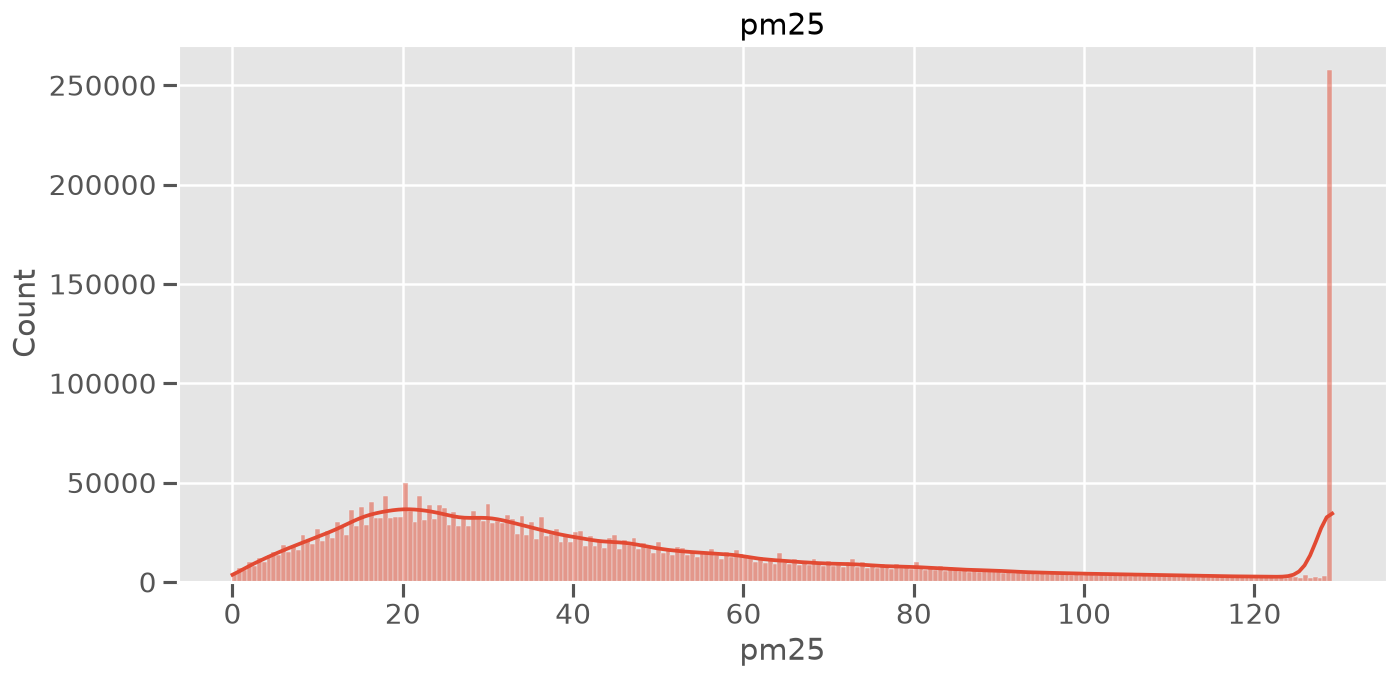

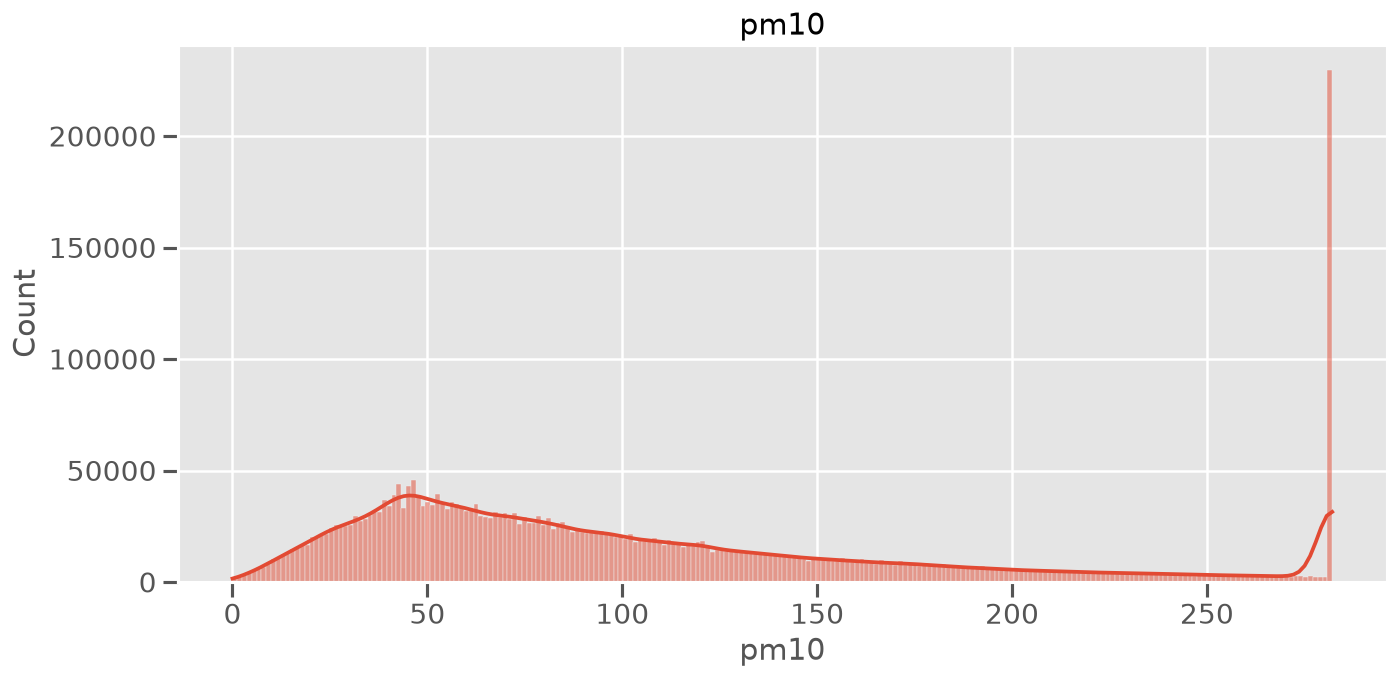

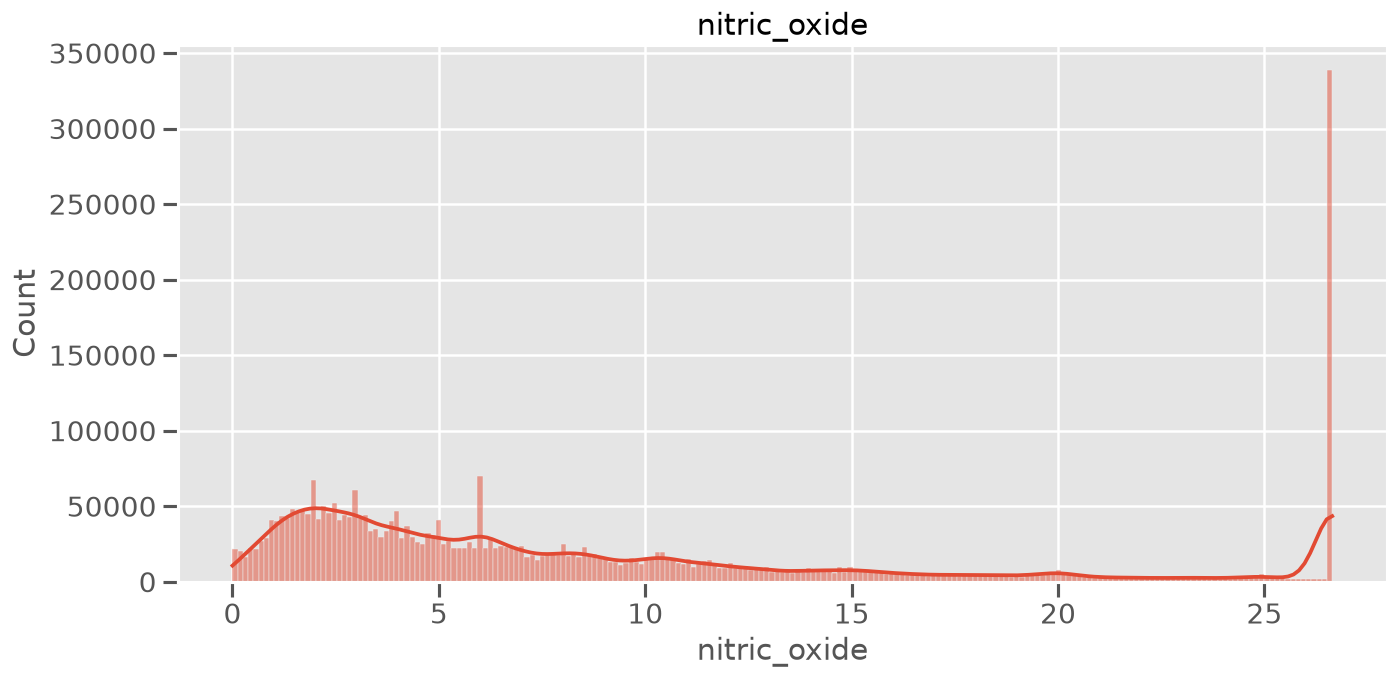

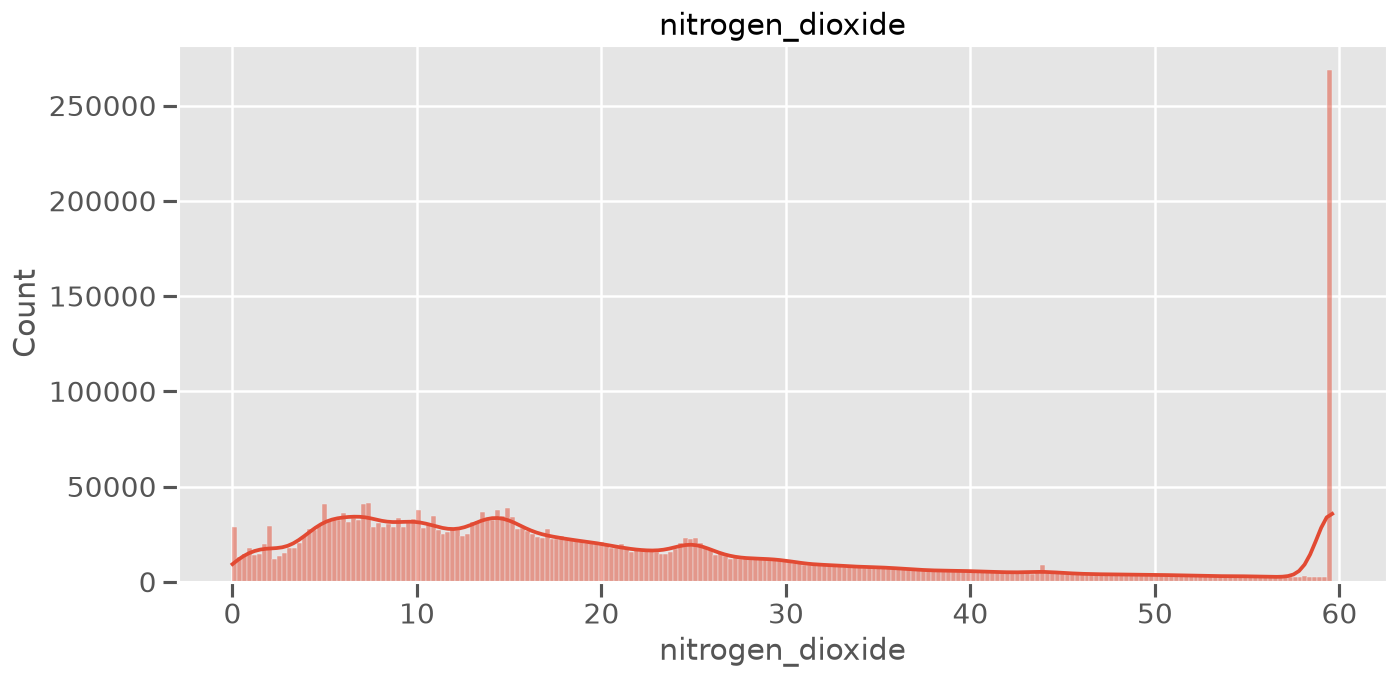

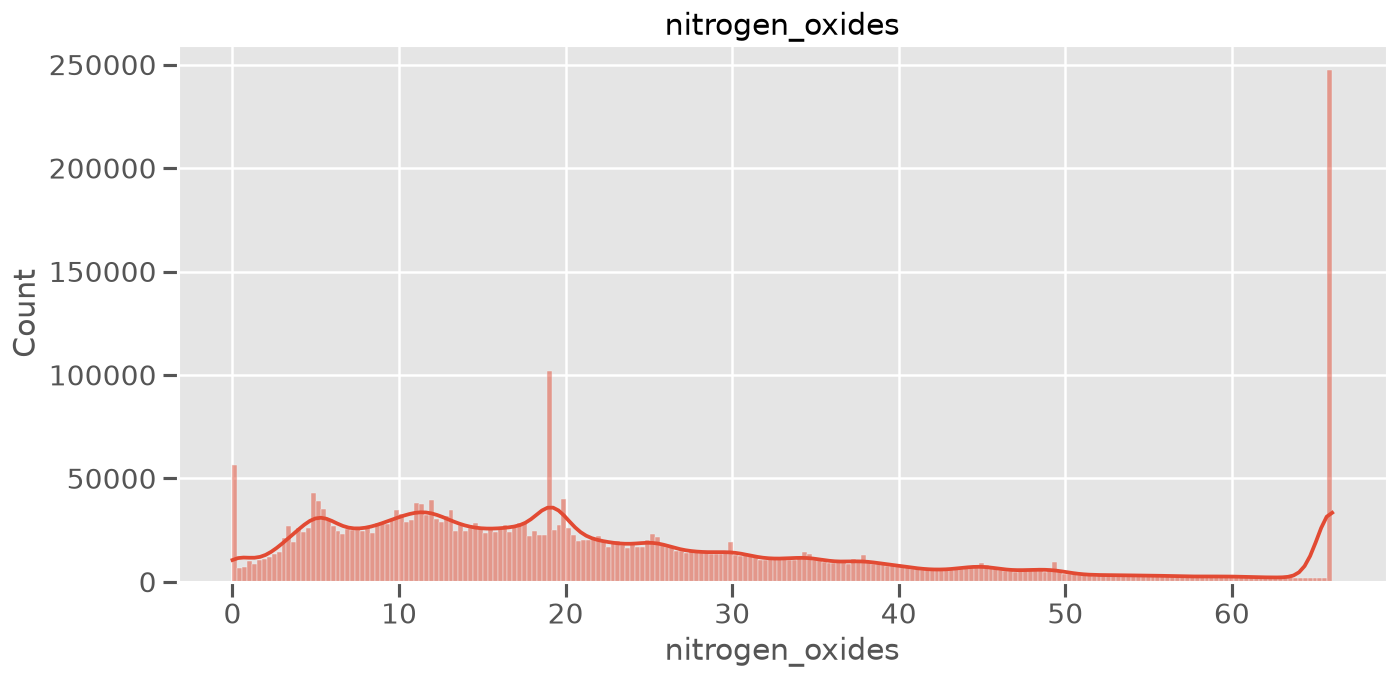

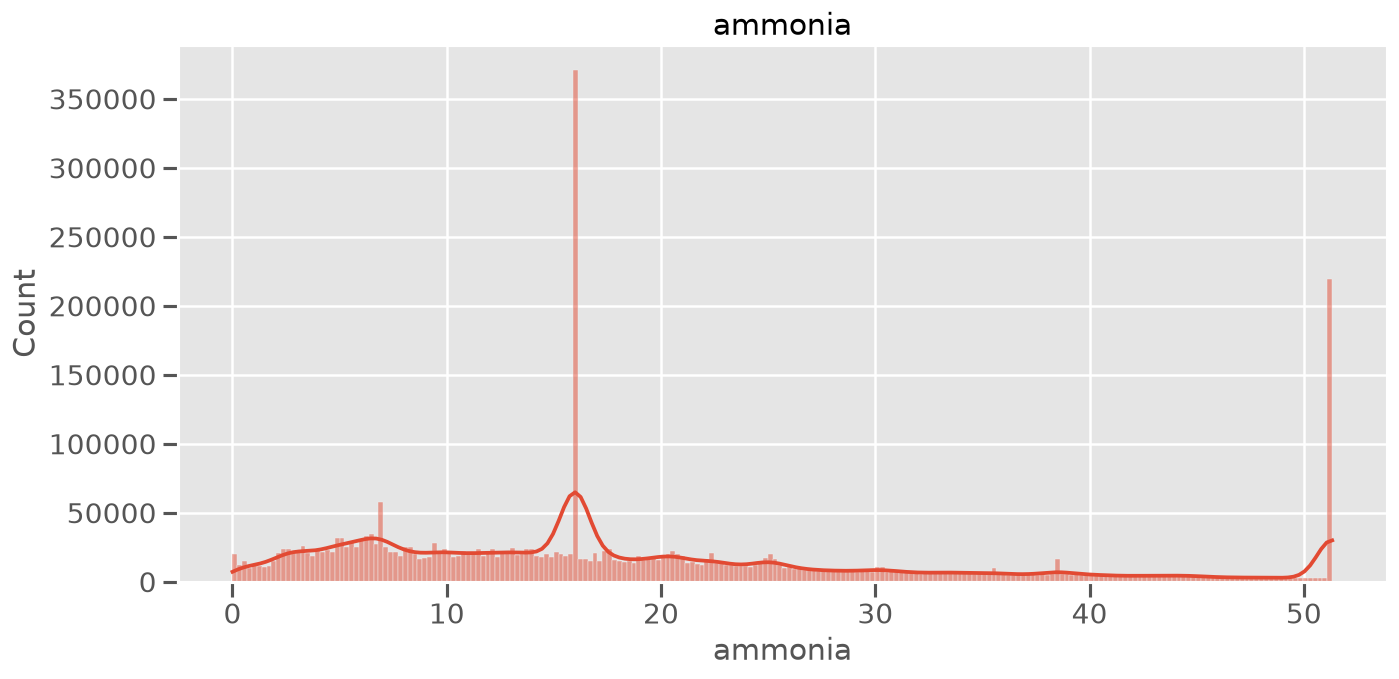

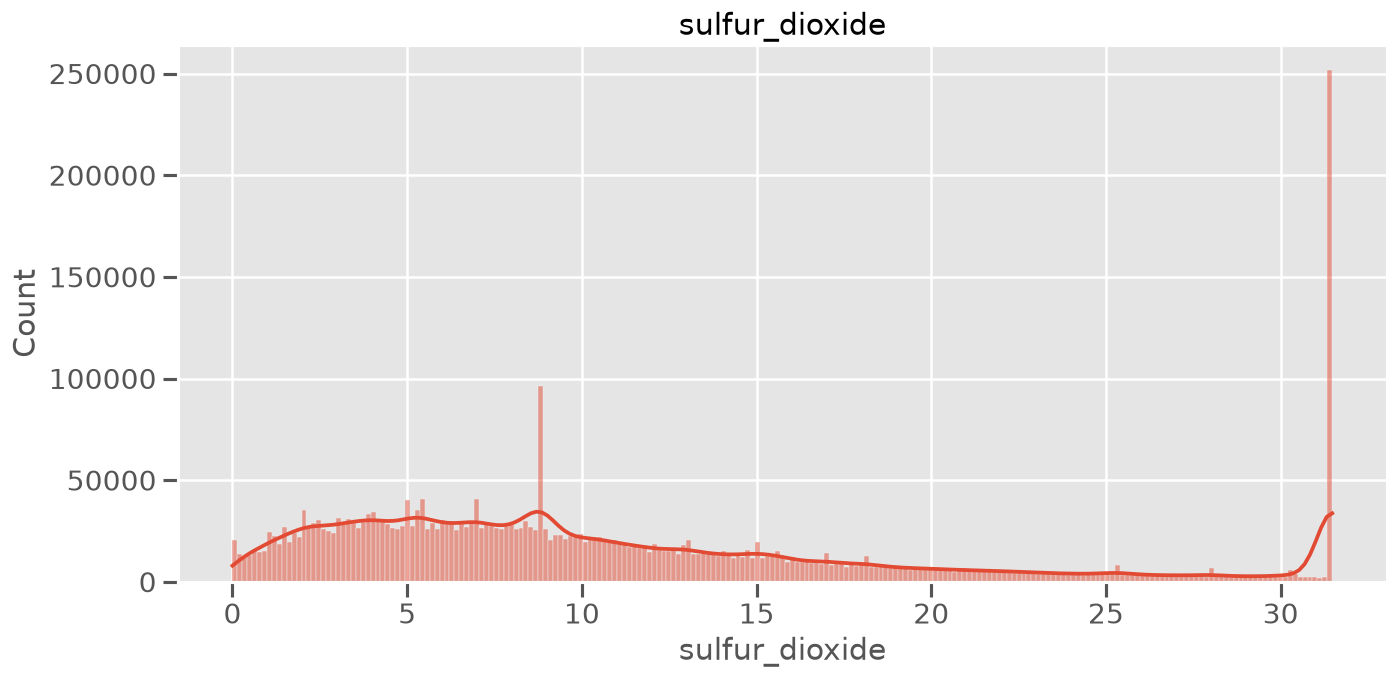

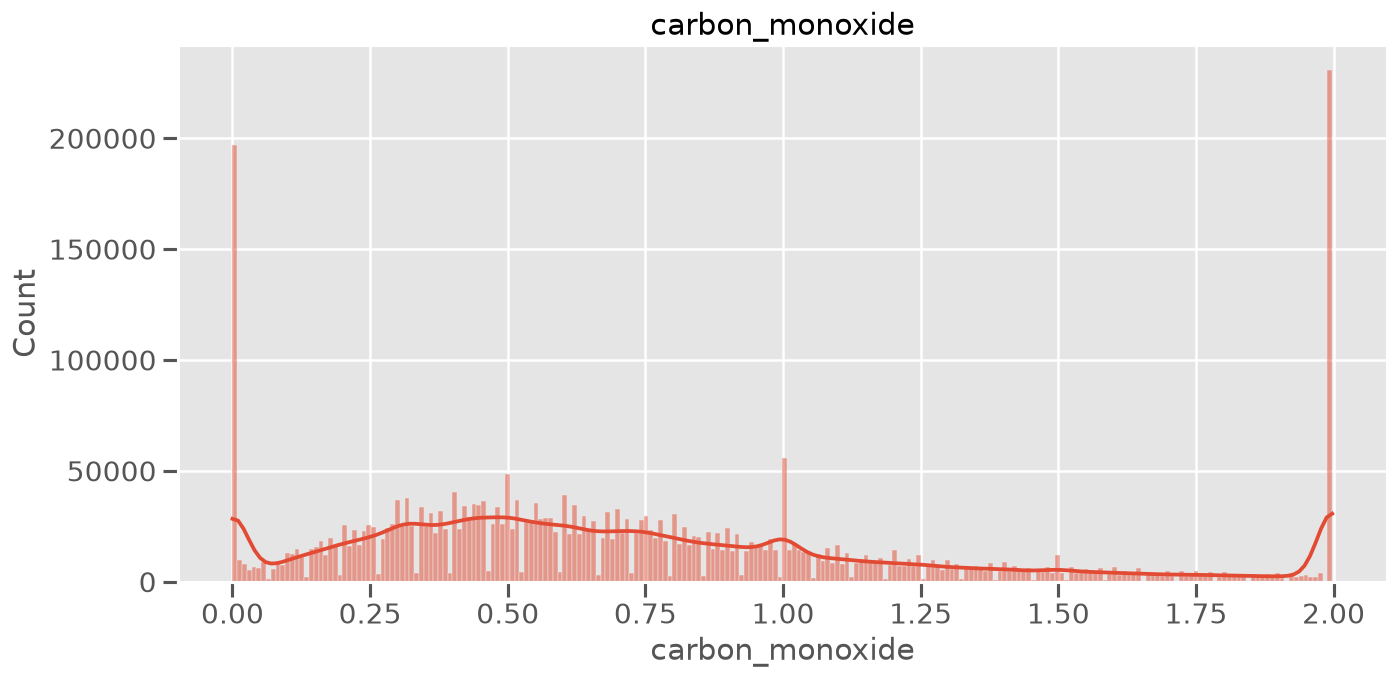

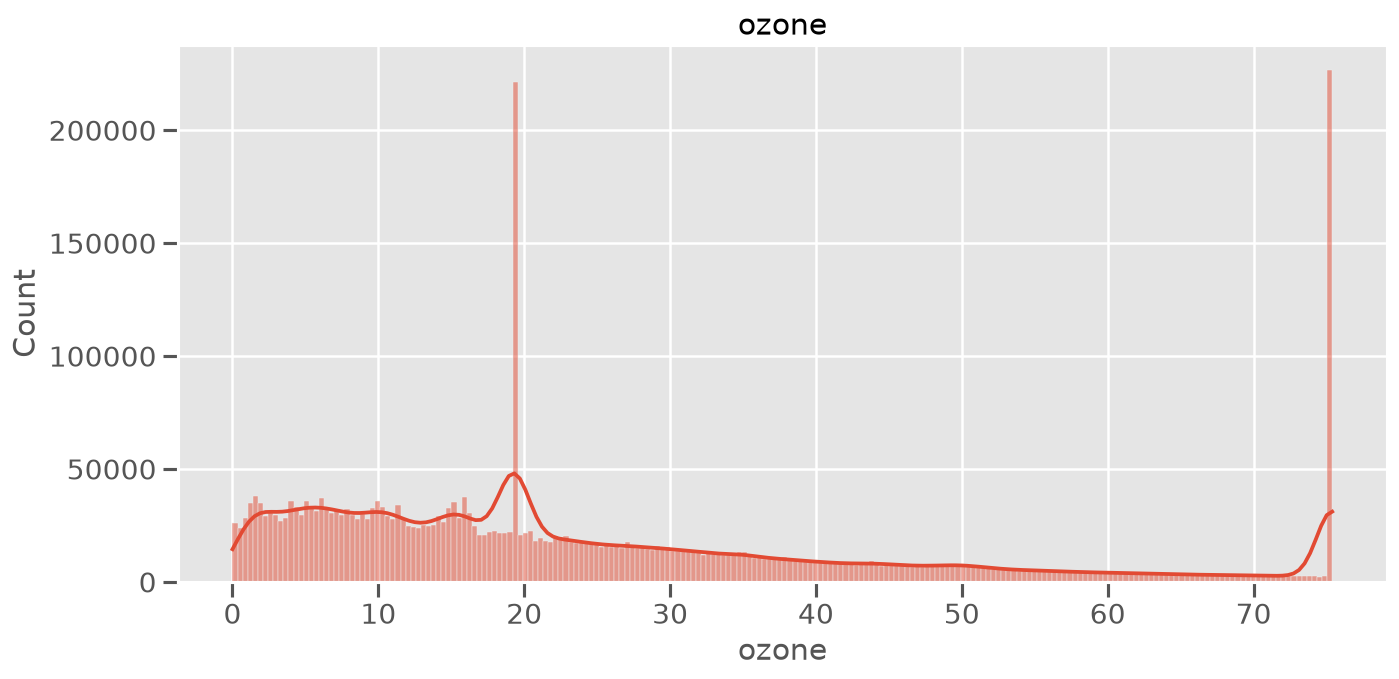

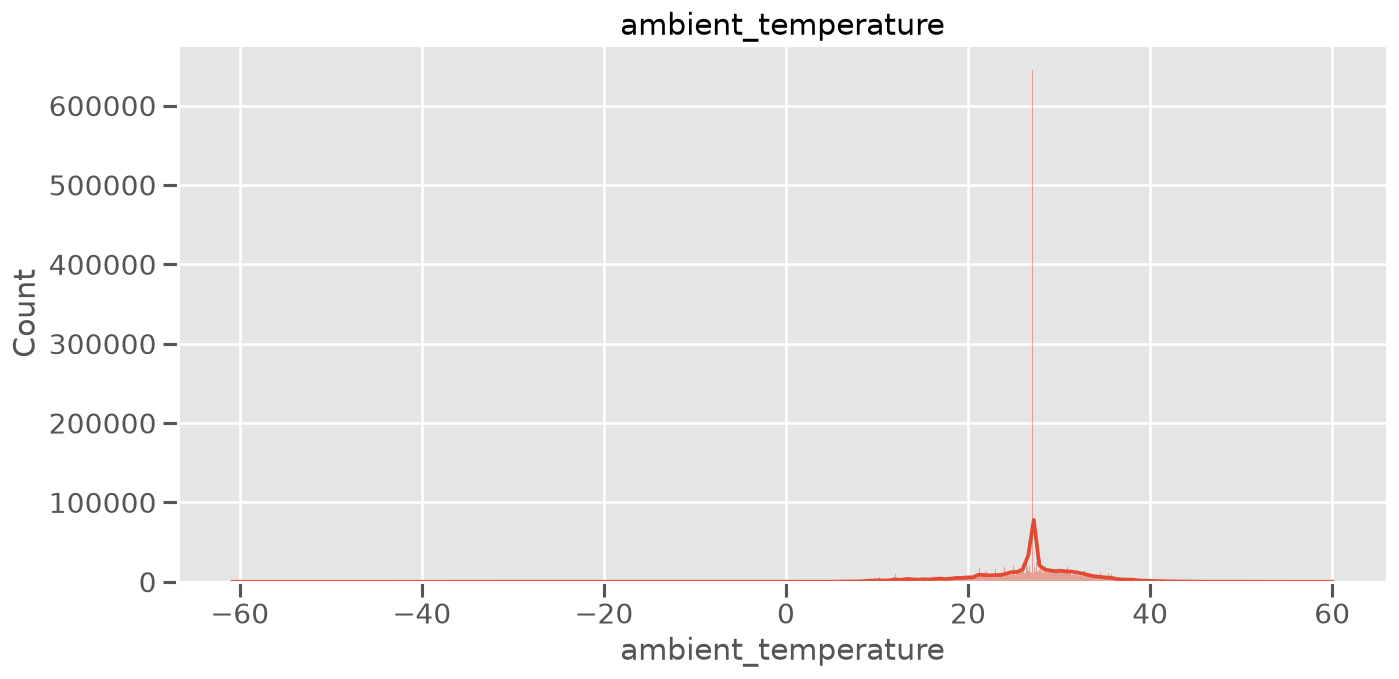

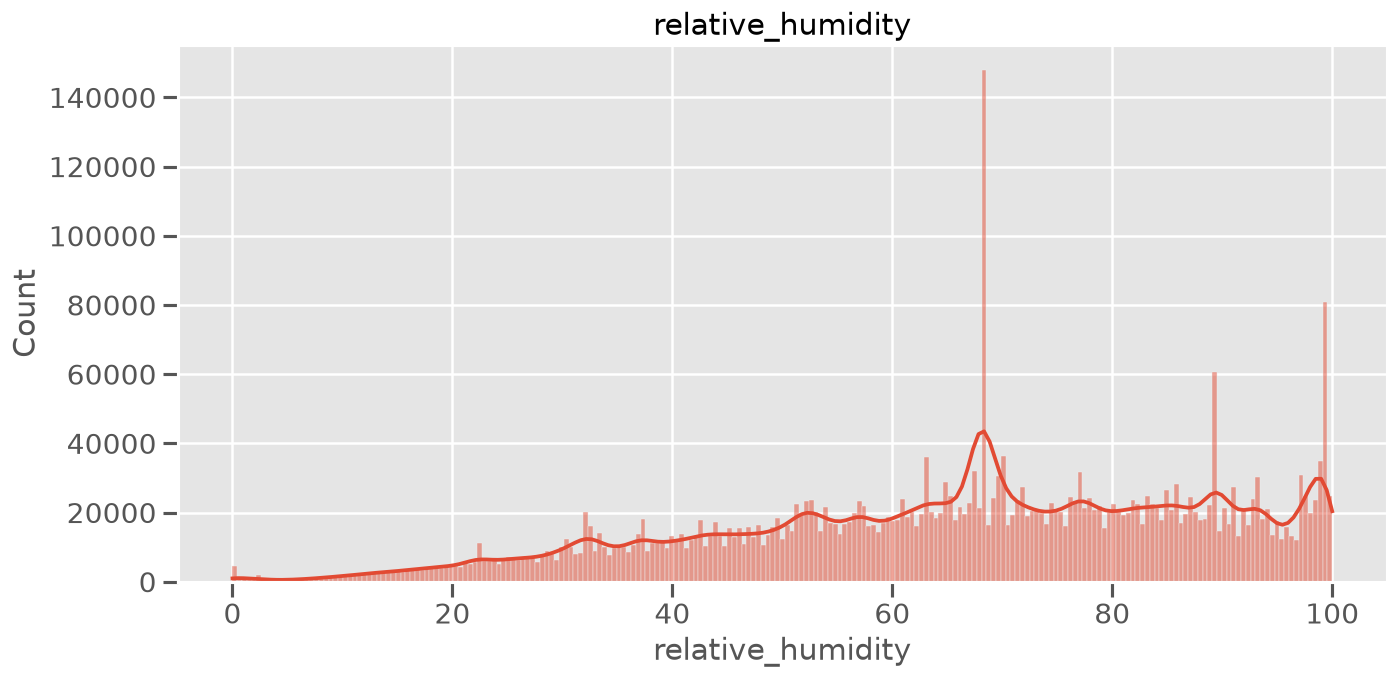

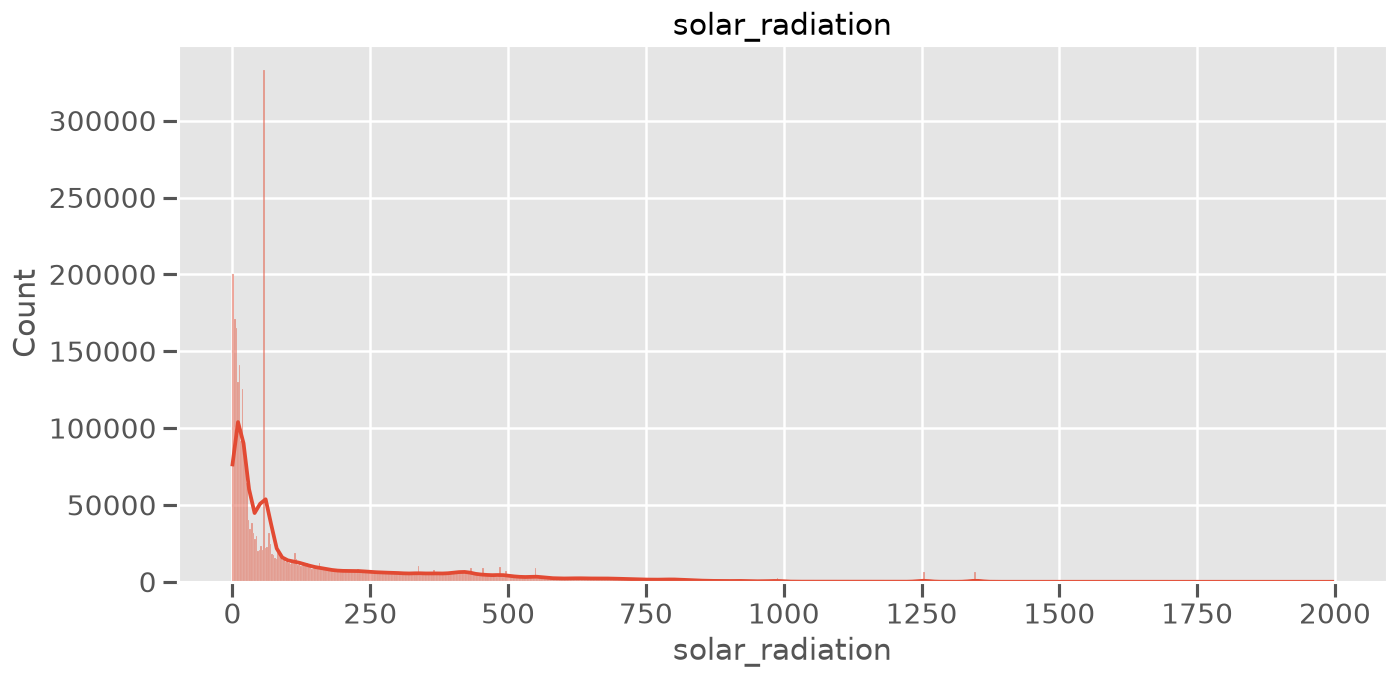

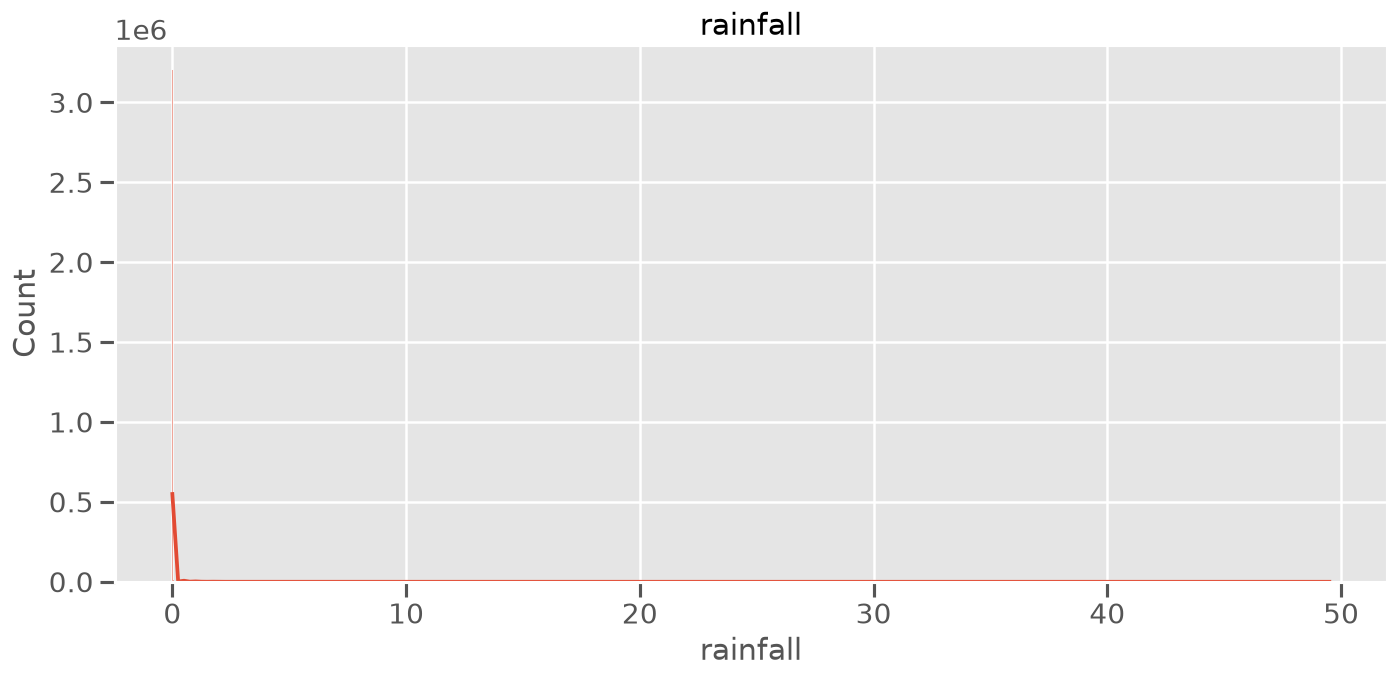

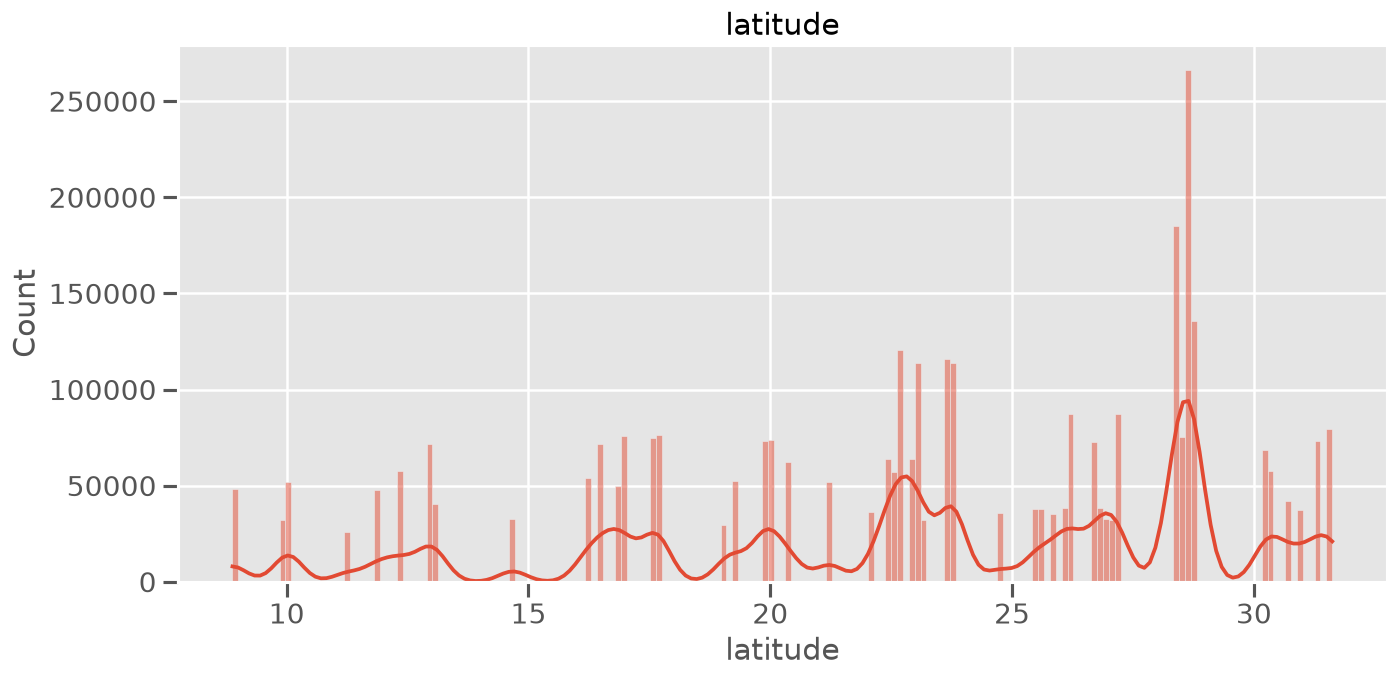

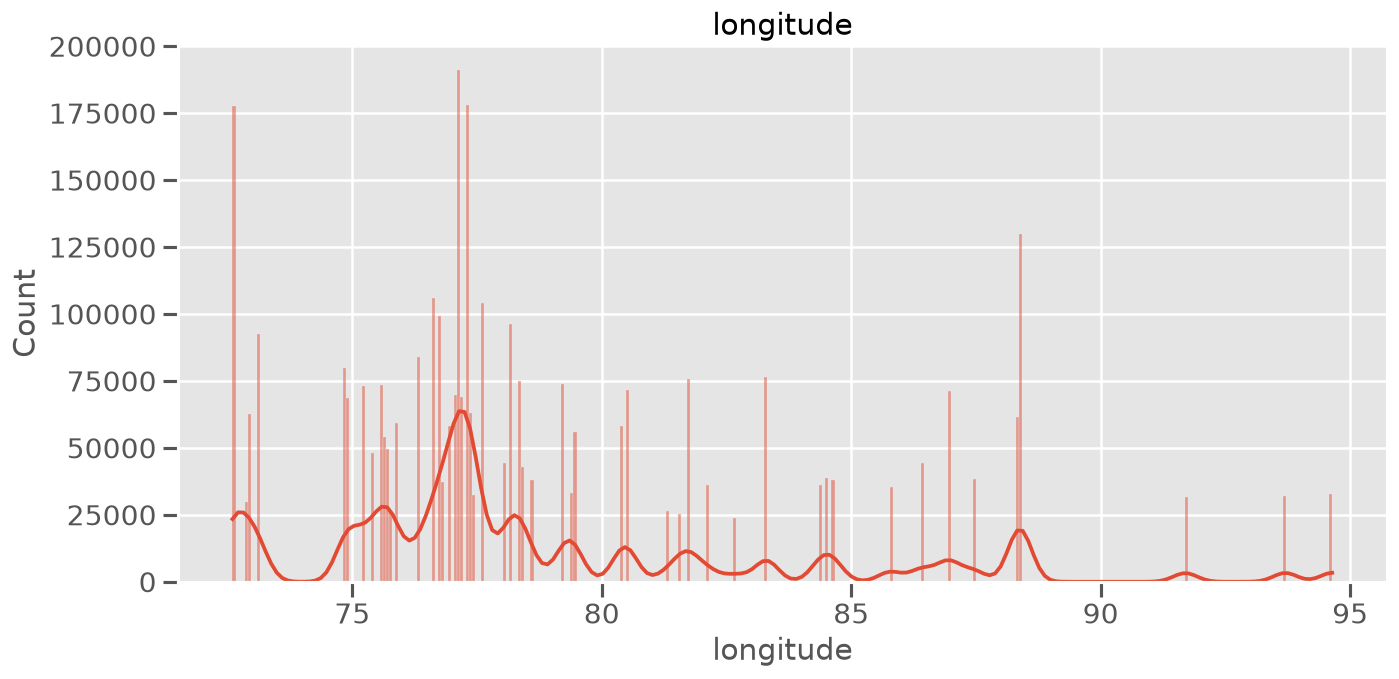

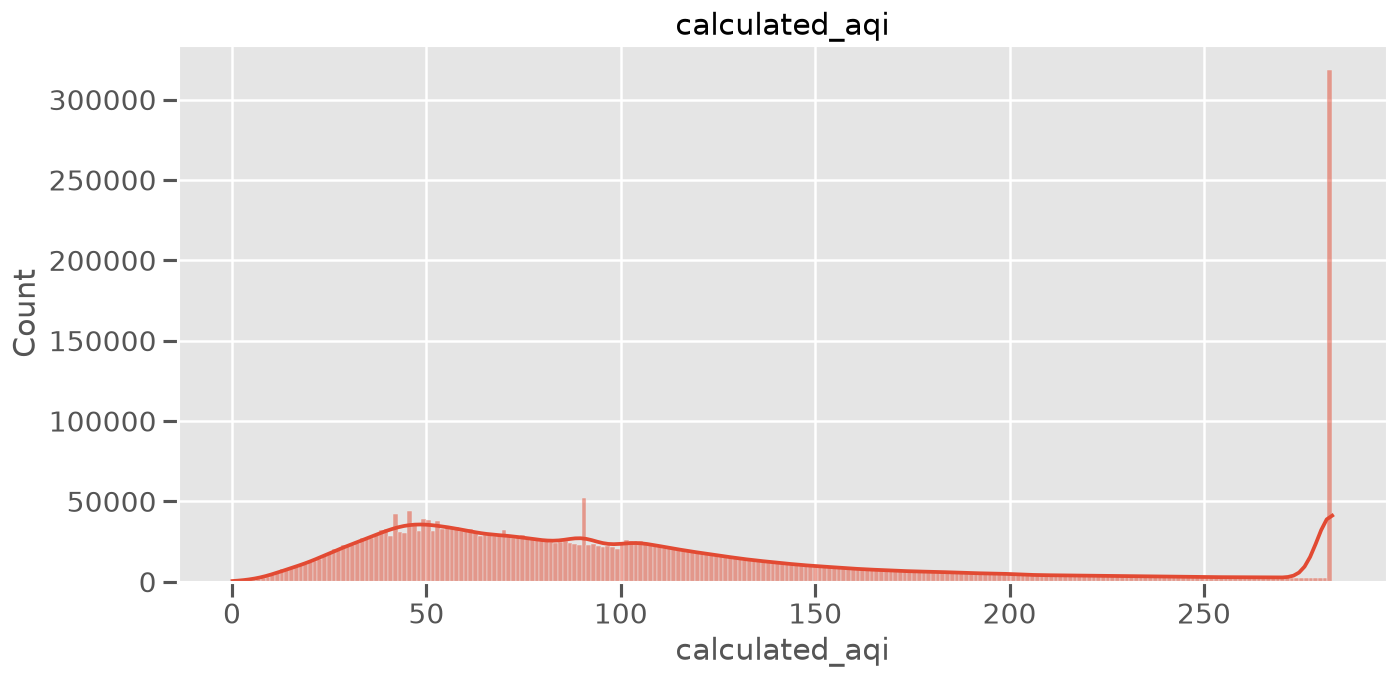

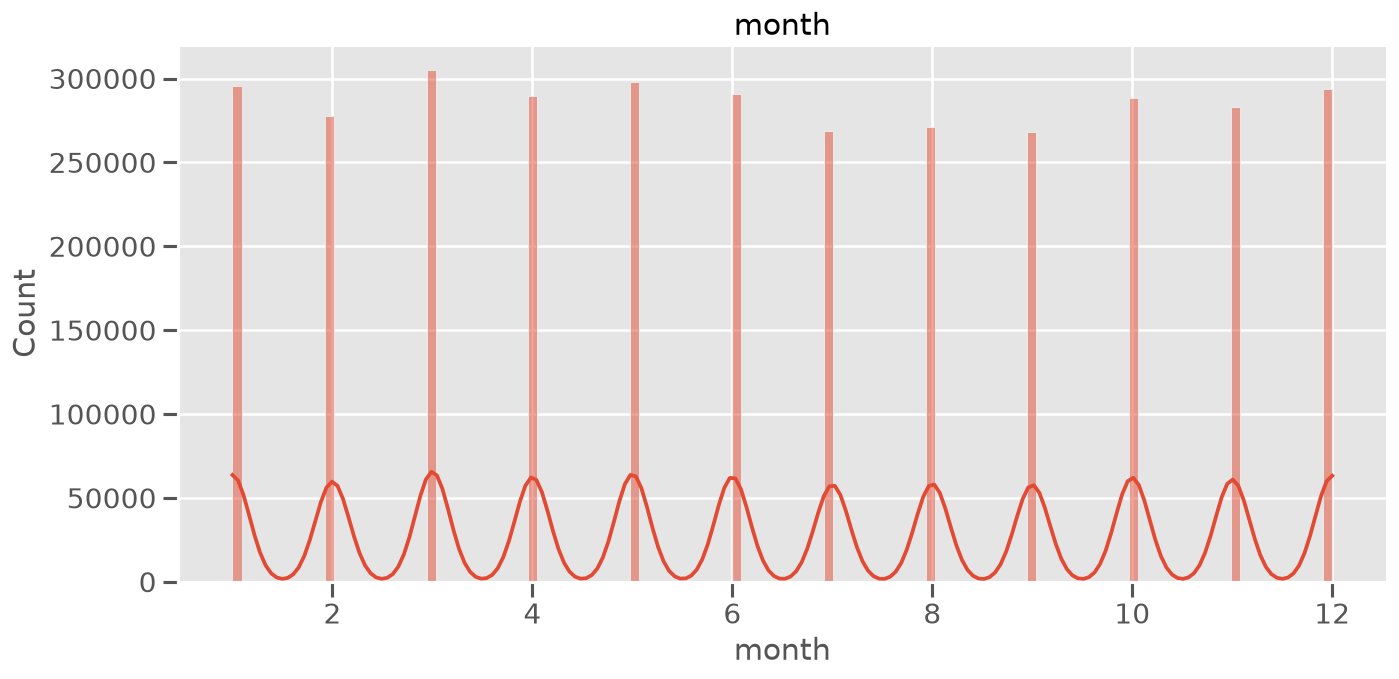

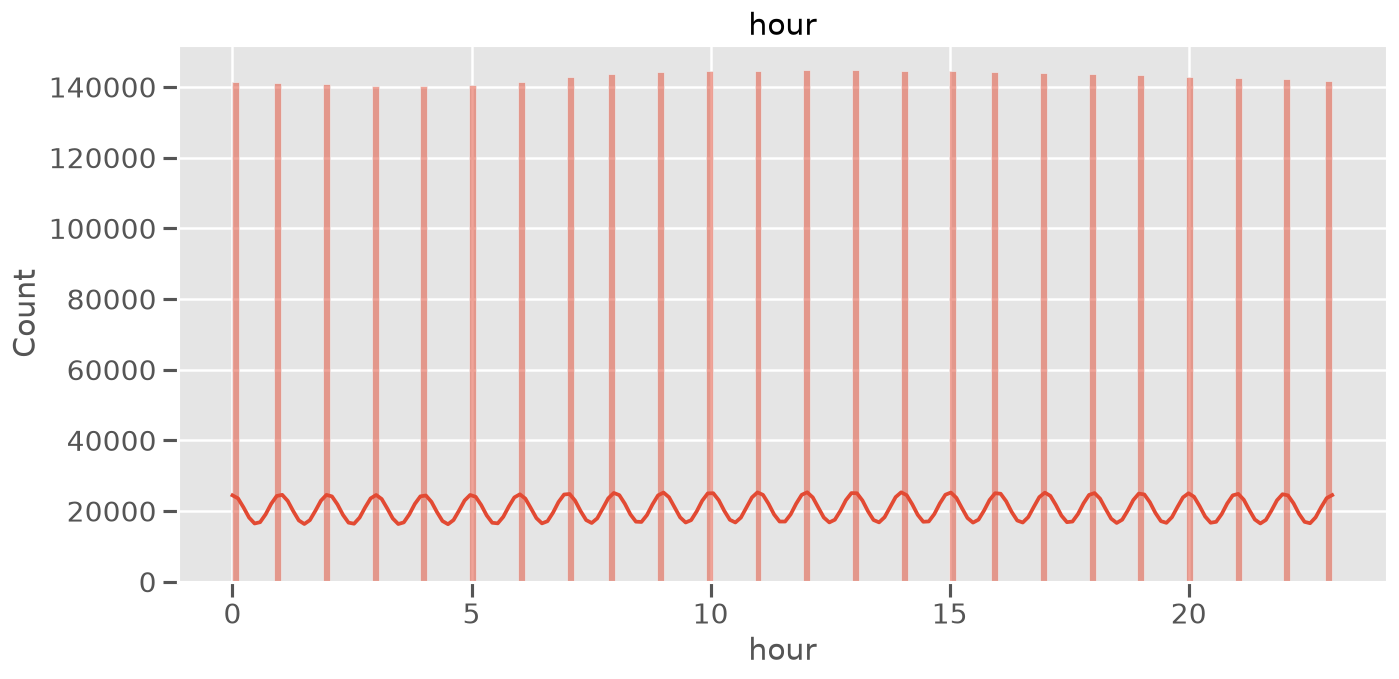

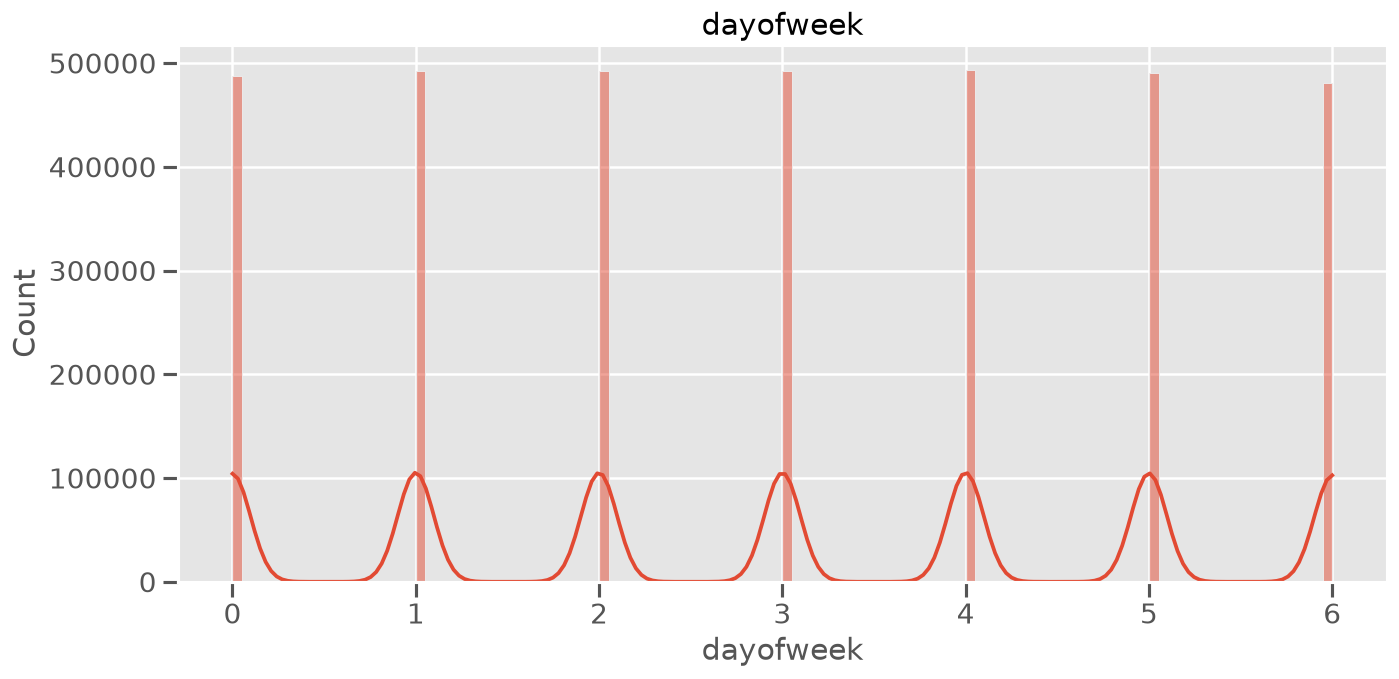

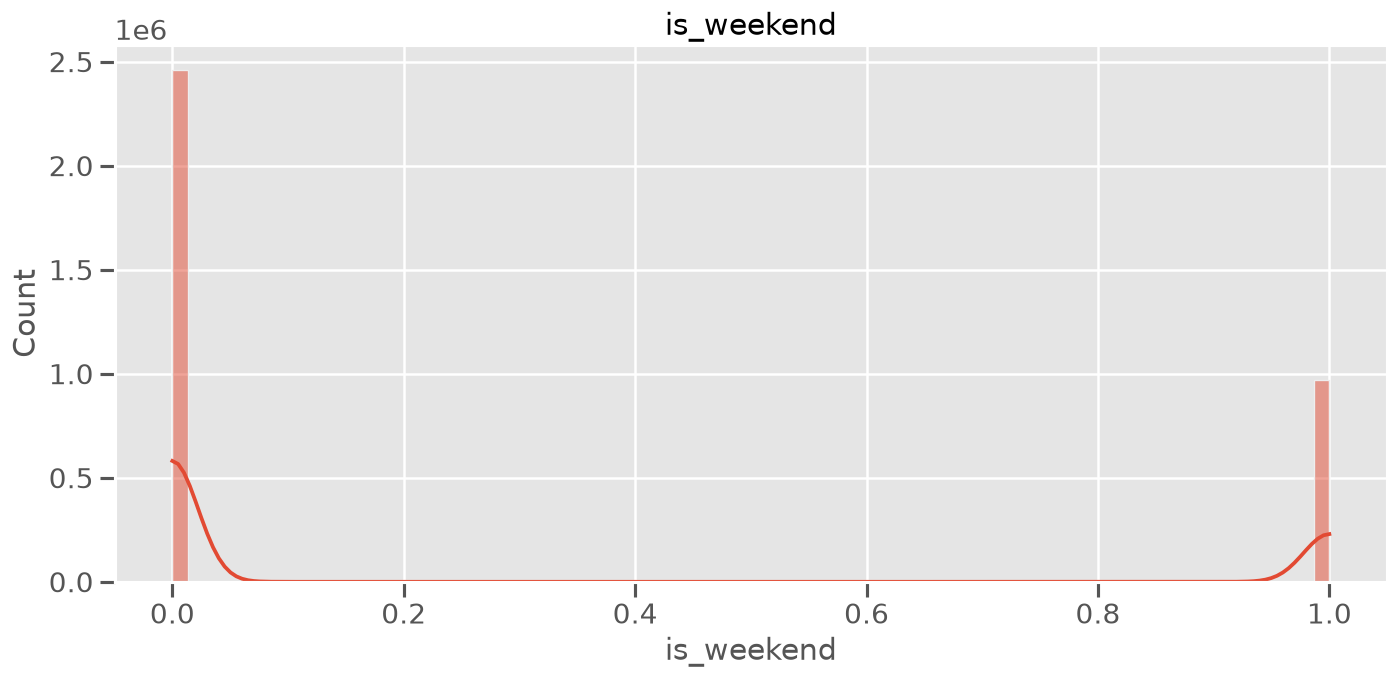

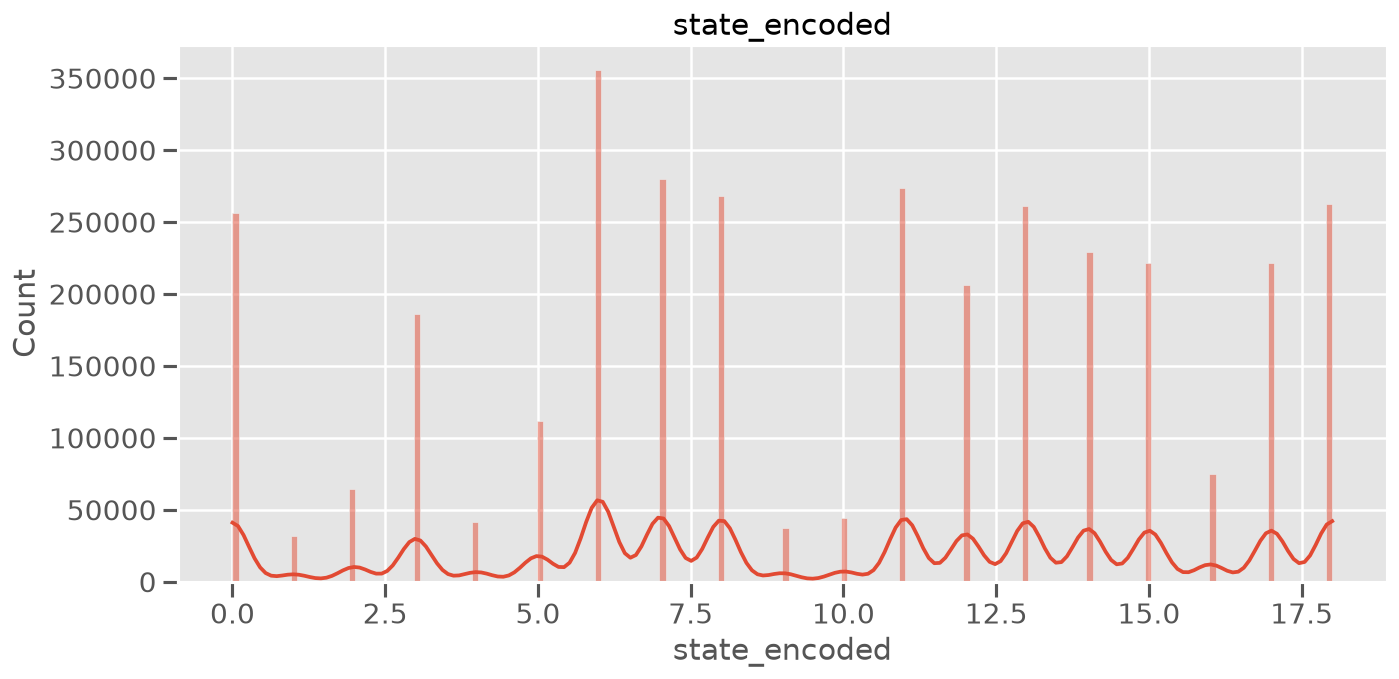

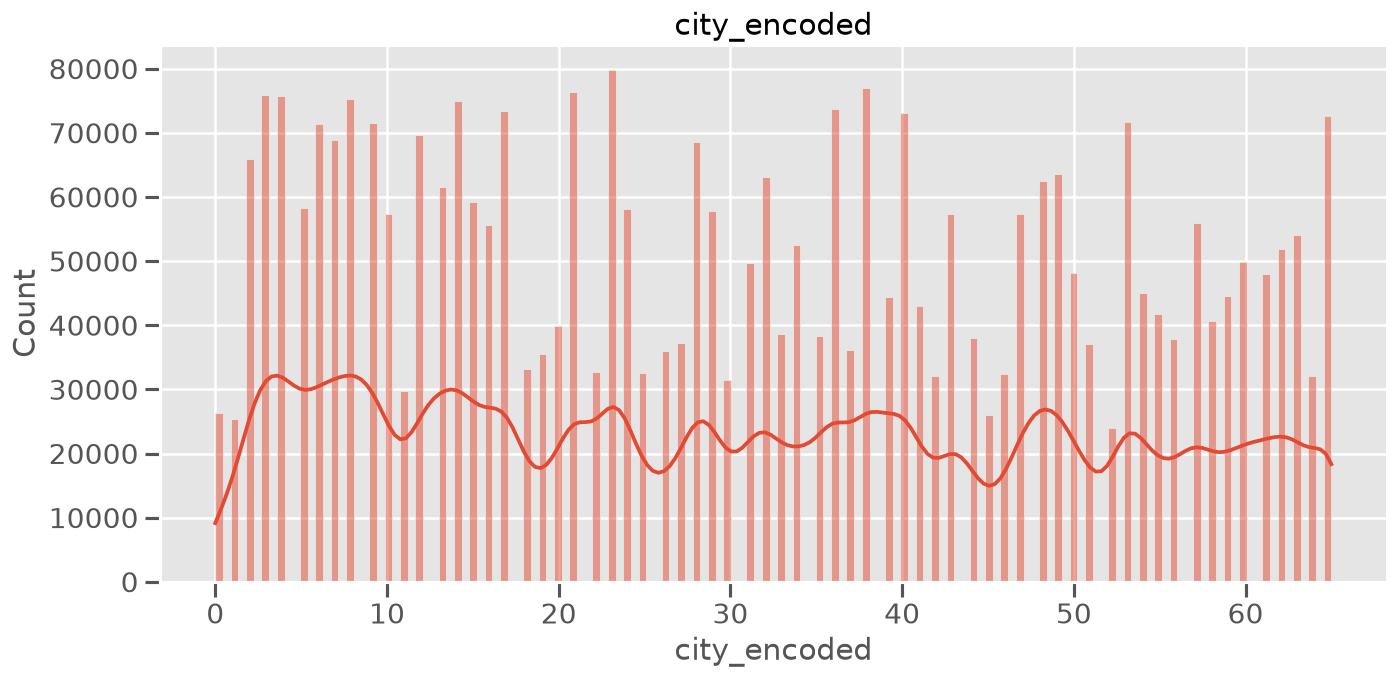

In [9]:
# Univariate Analysis
for col in numeric_columns:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR/f"{col}_distribution.png")
    plt.show()

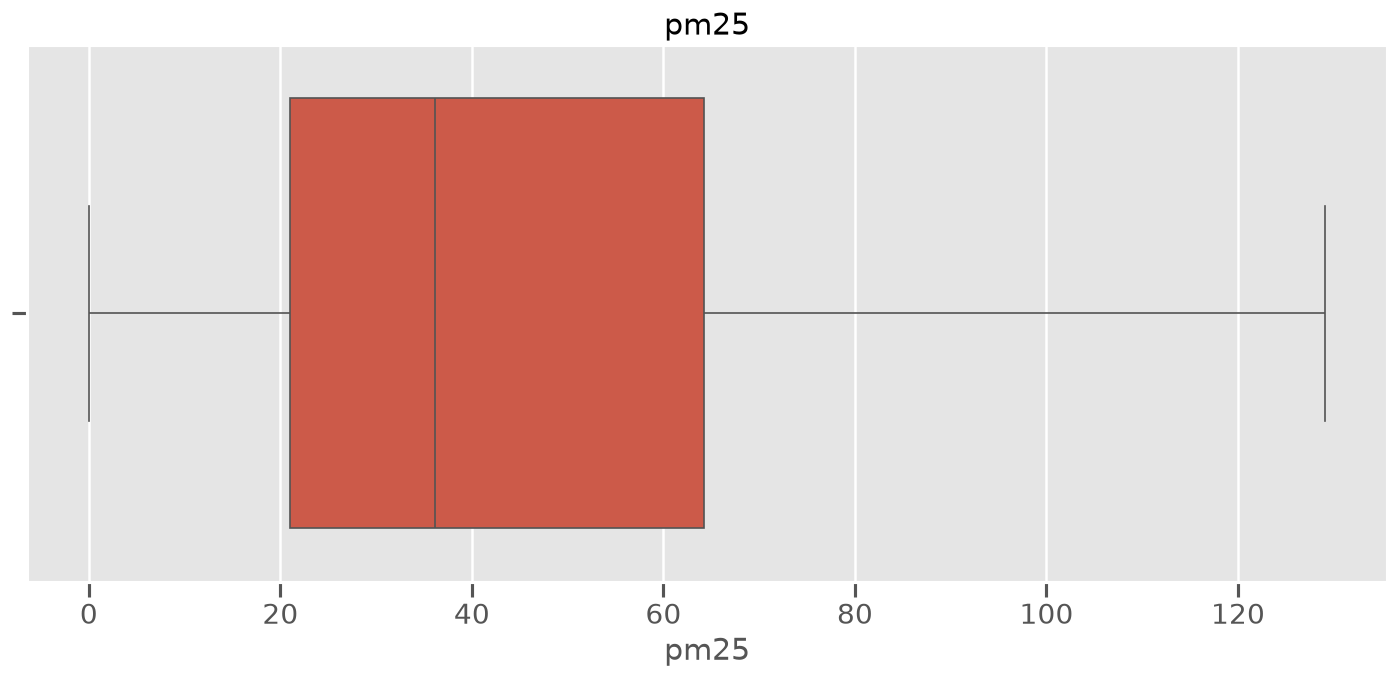

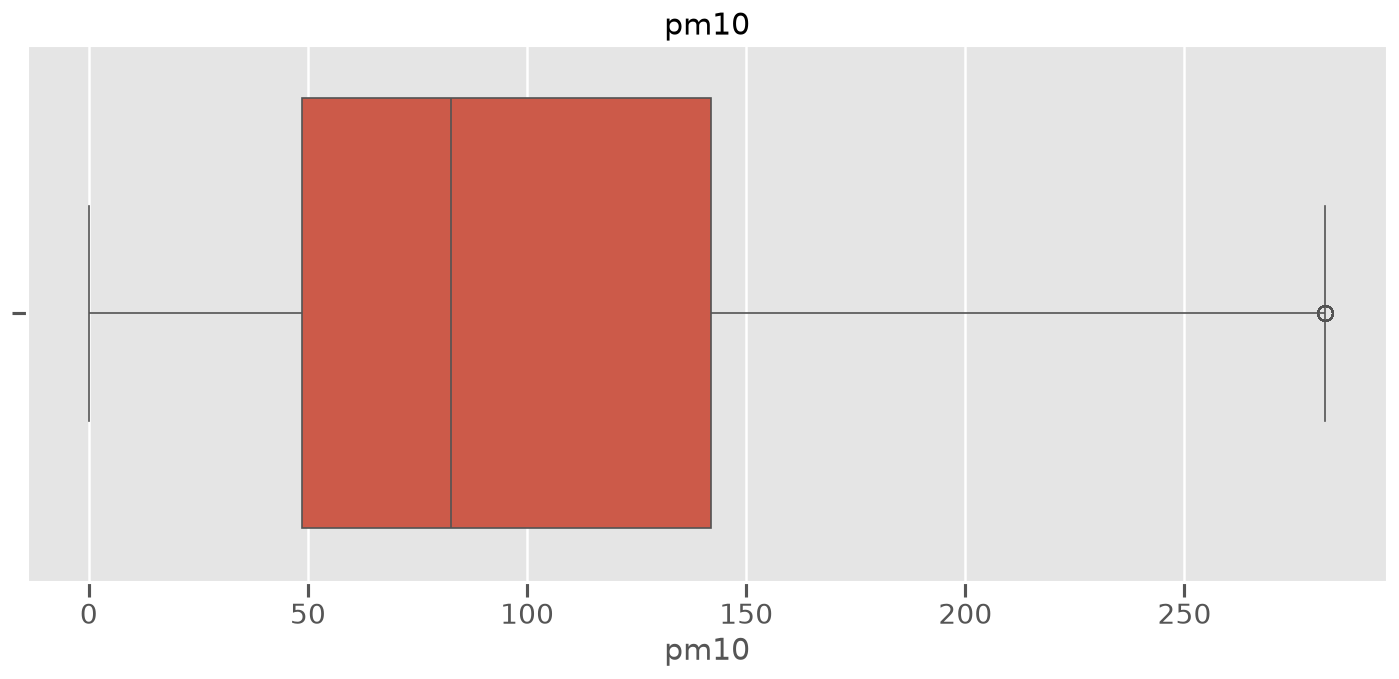

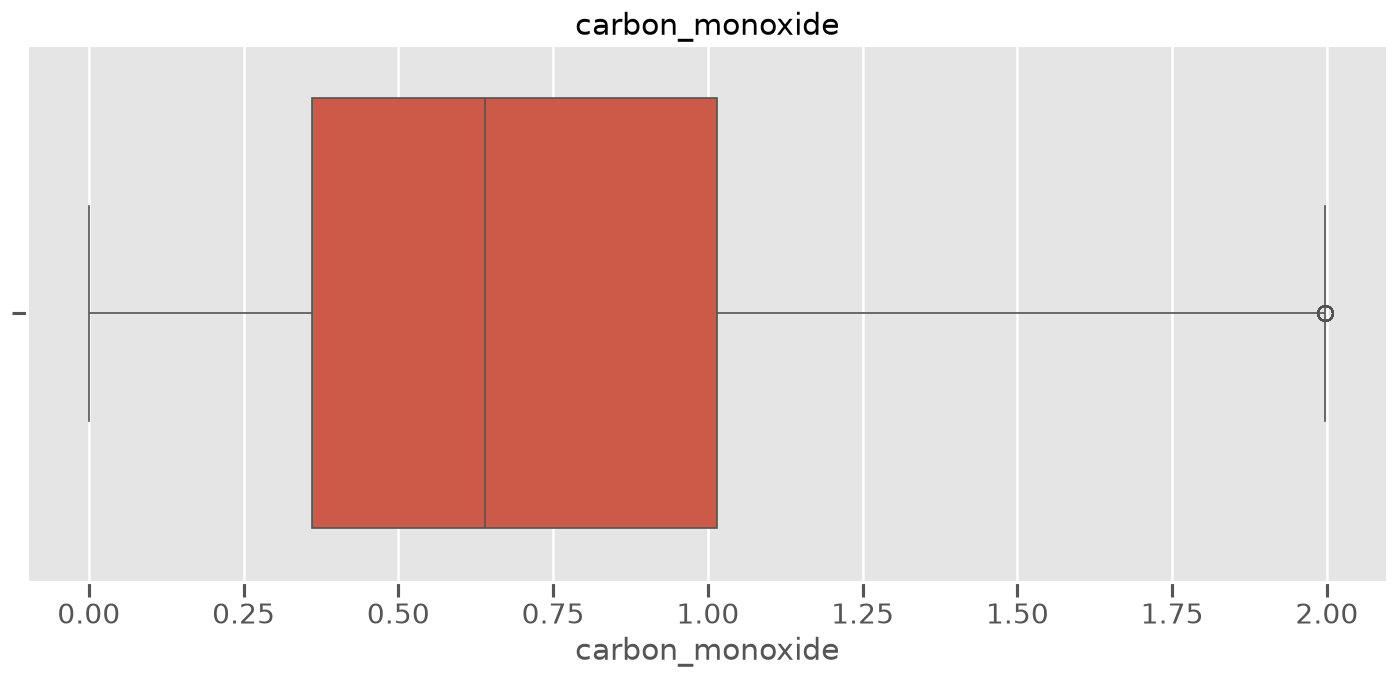

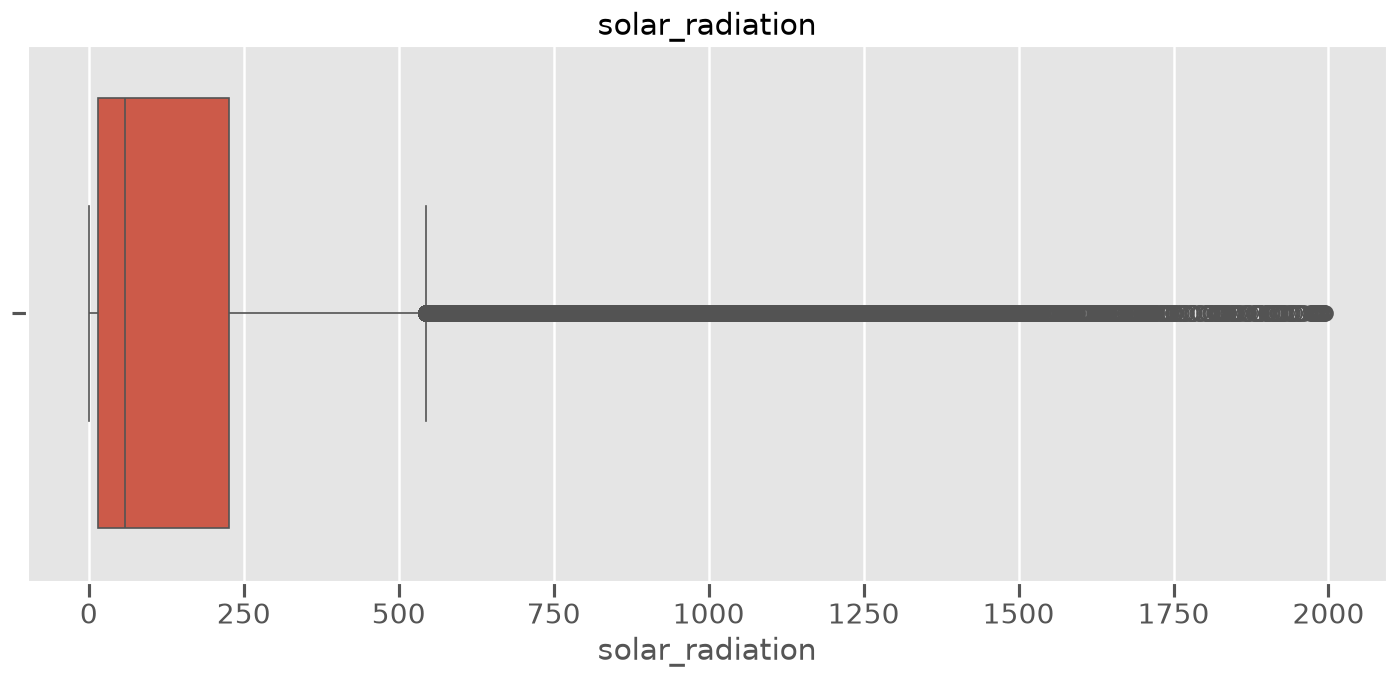

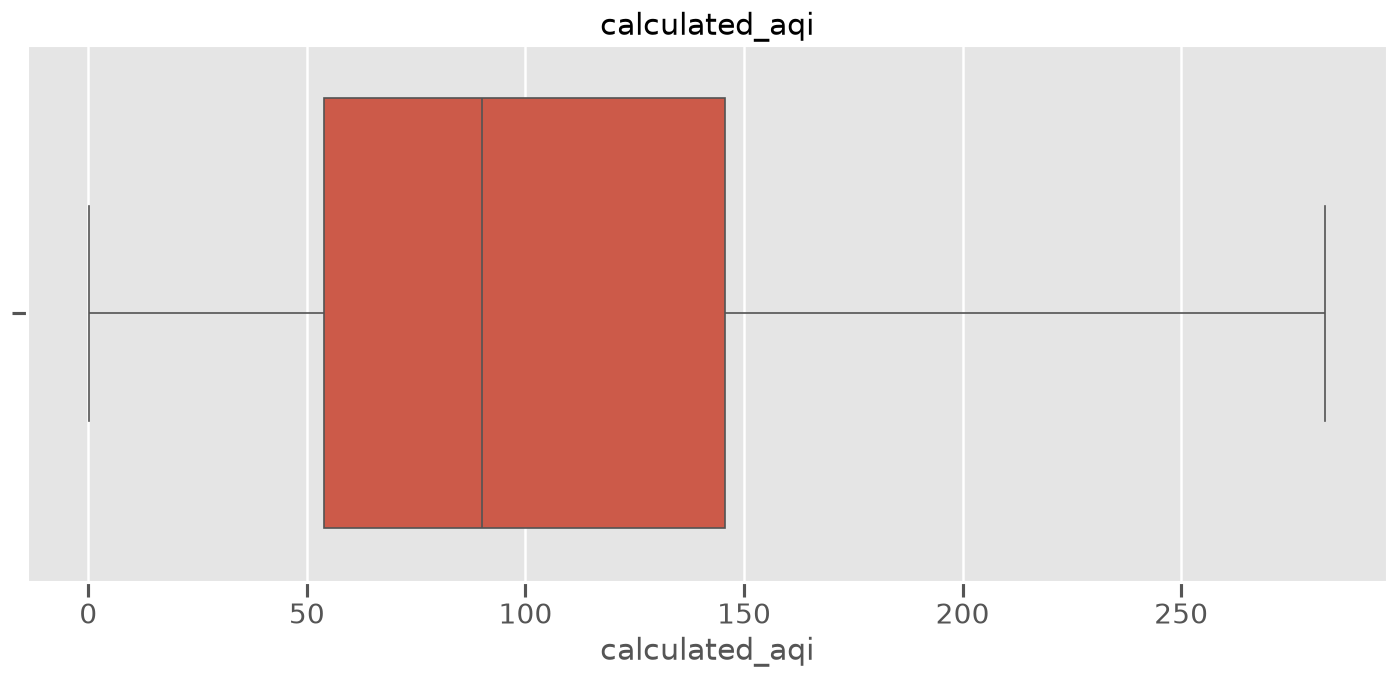

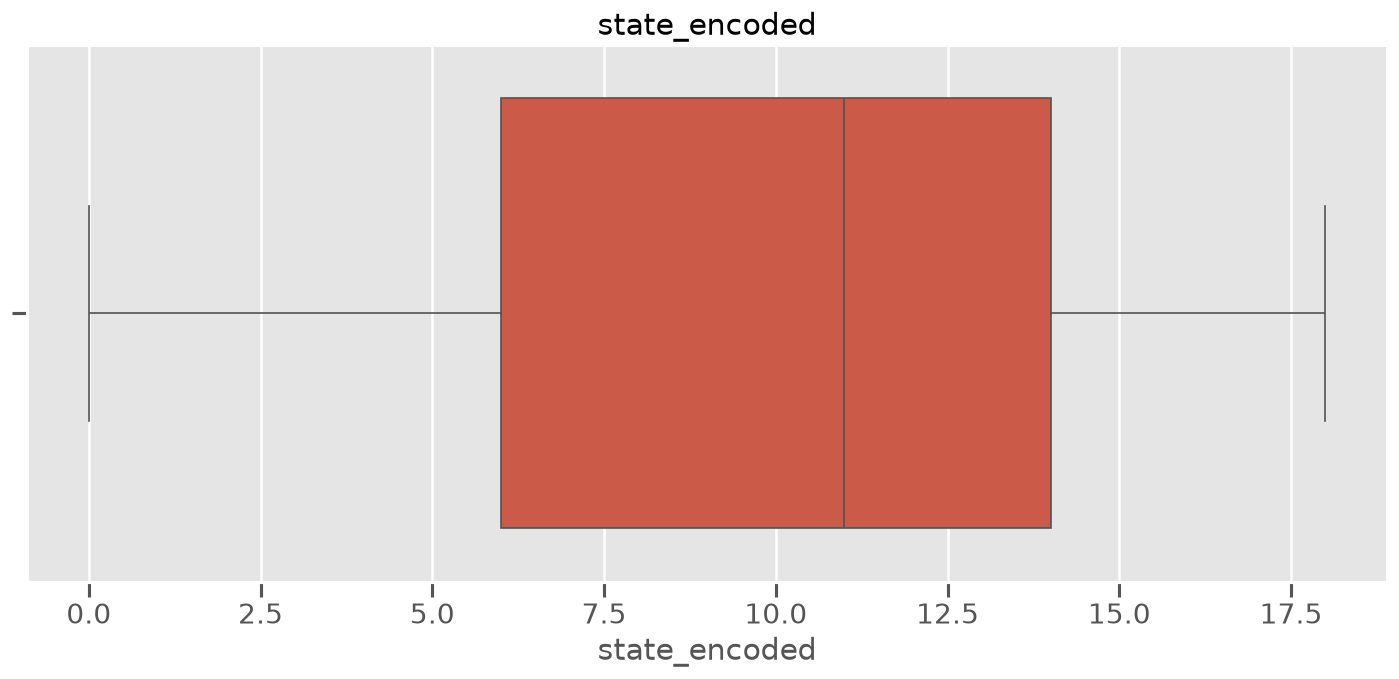

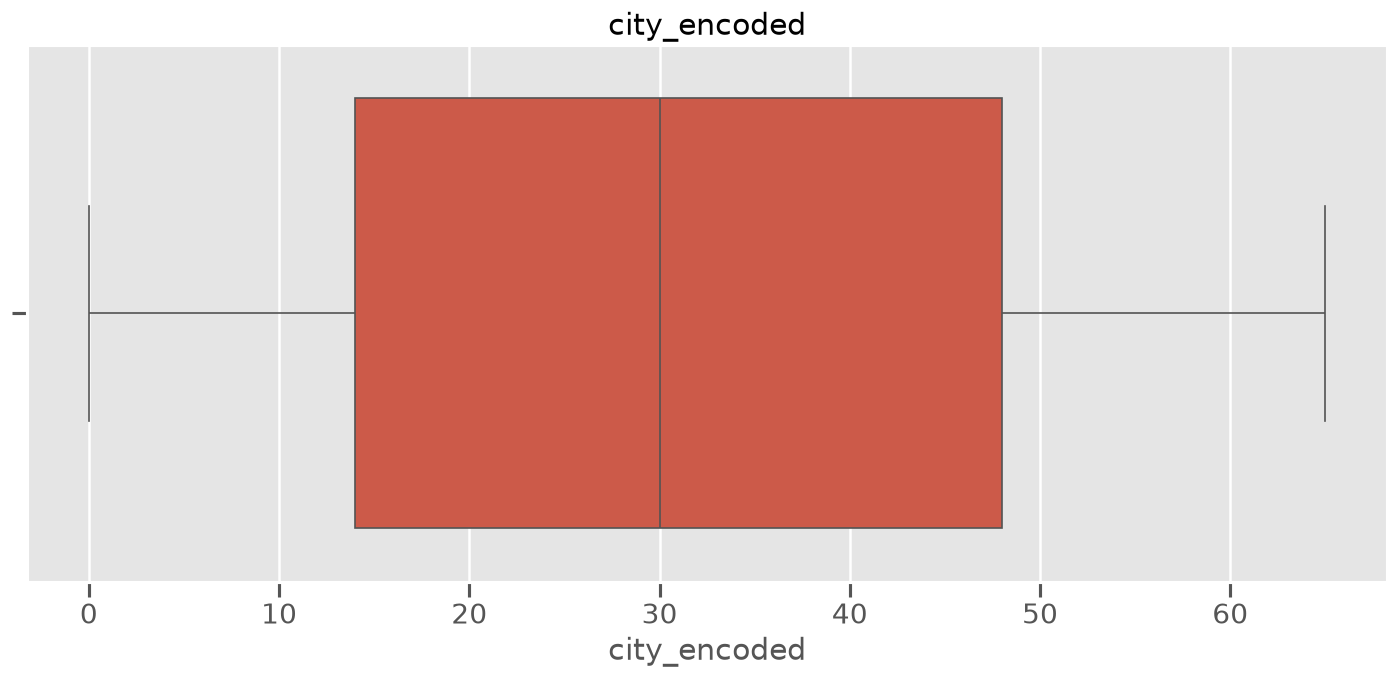

In [10]:
# Boxplot
for col in pollutant_columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR/f"{col}_boxplot.png")
    plt.show()

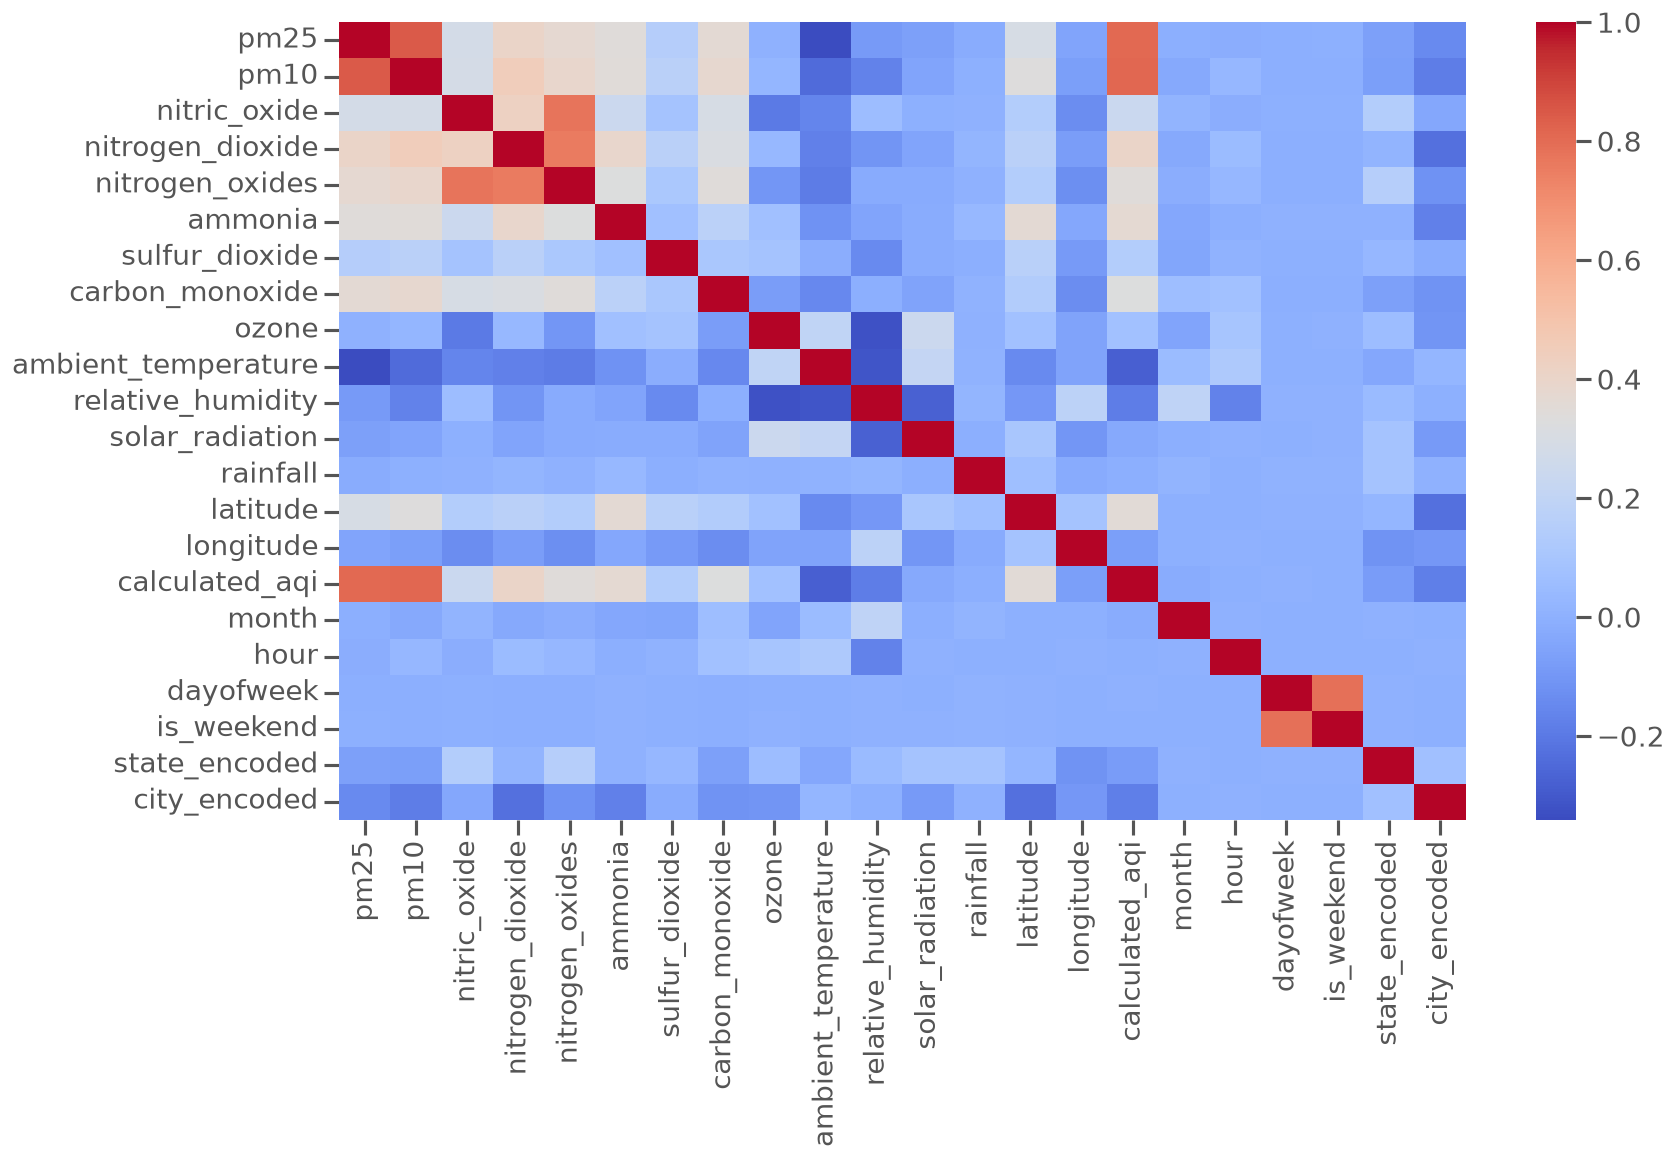

In [11]:
# Correlation Matrix
corr = df[numeric_columns].corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR/"correlation_heatmap.png")
plt.show()

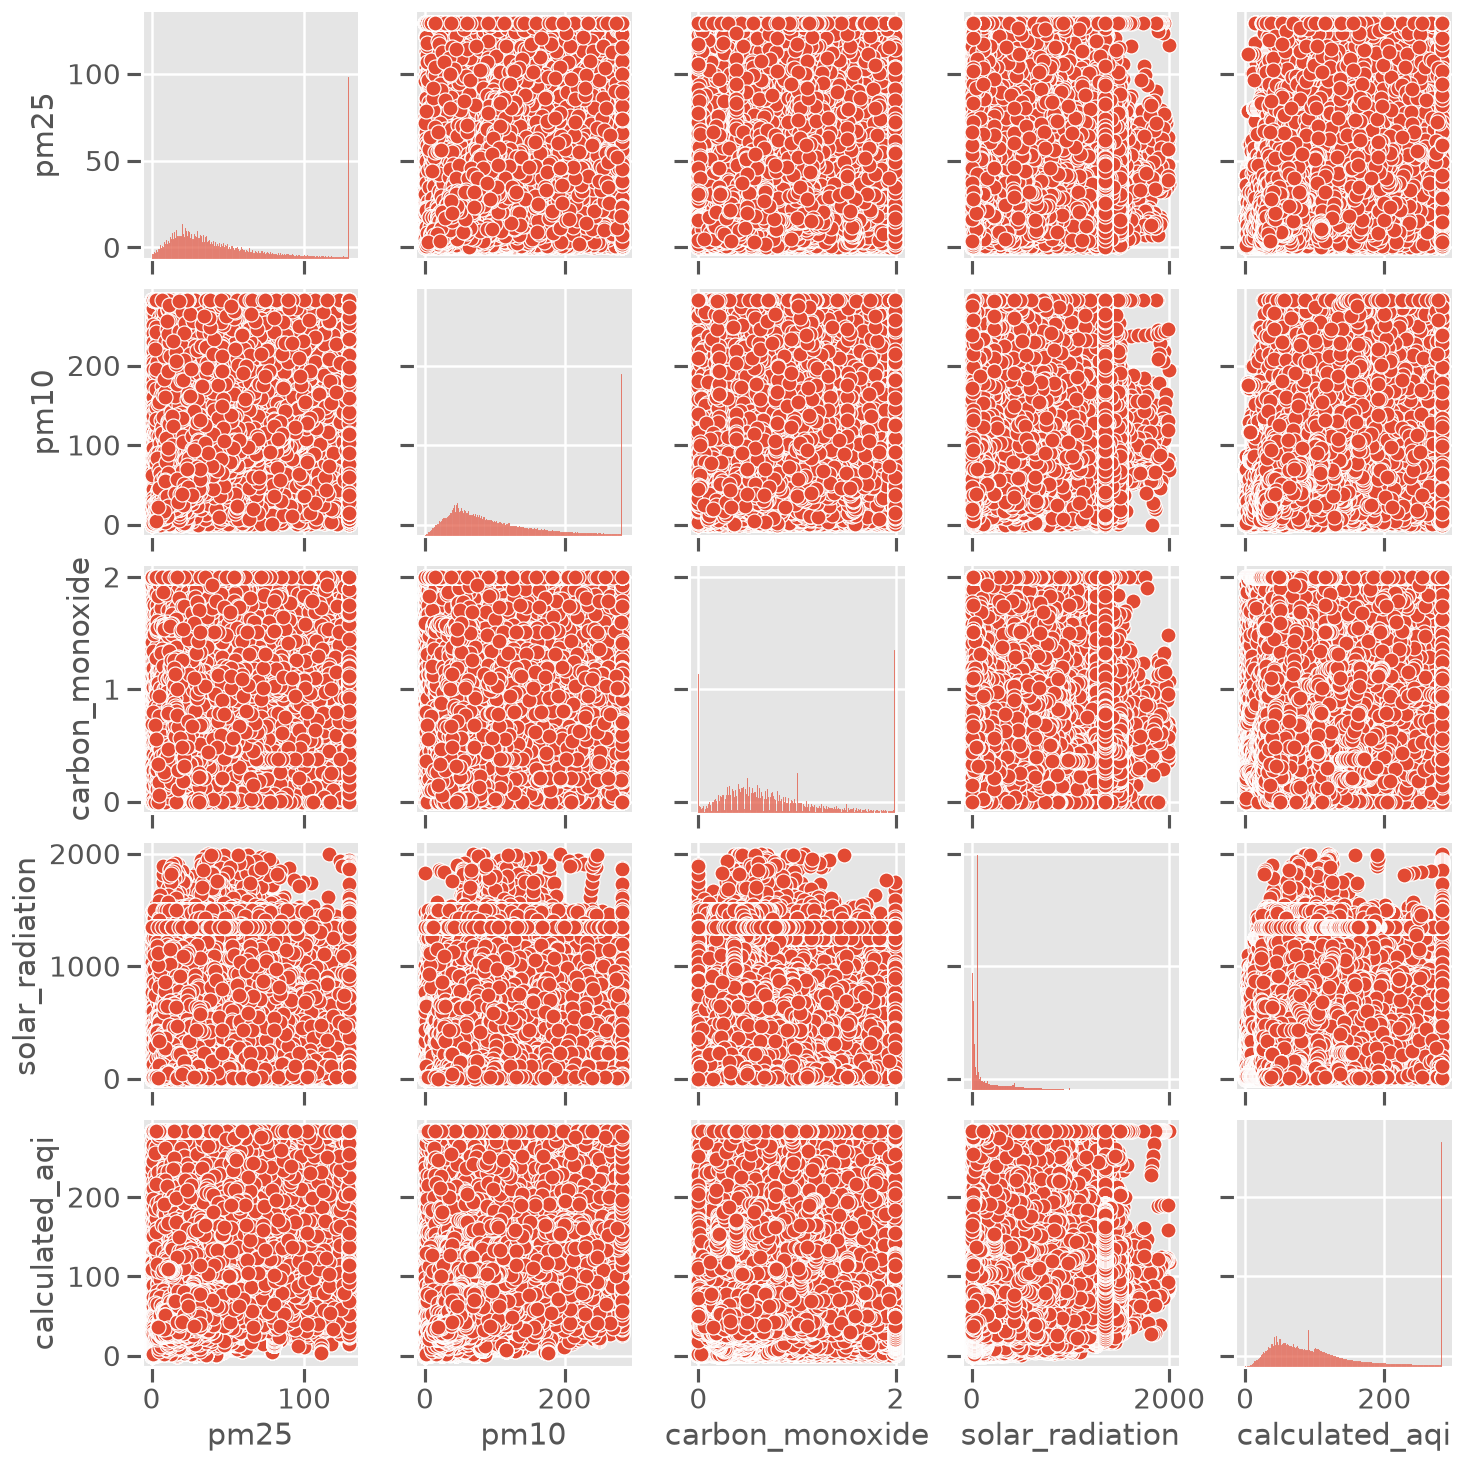

In [12]:
# Pairplot
sample_cols = pollutant_columns[:5]
sns.pairplot(df[sample_cols])
plt.show()

# Pollution trend over time.

In [13]:
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")

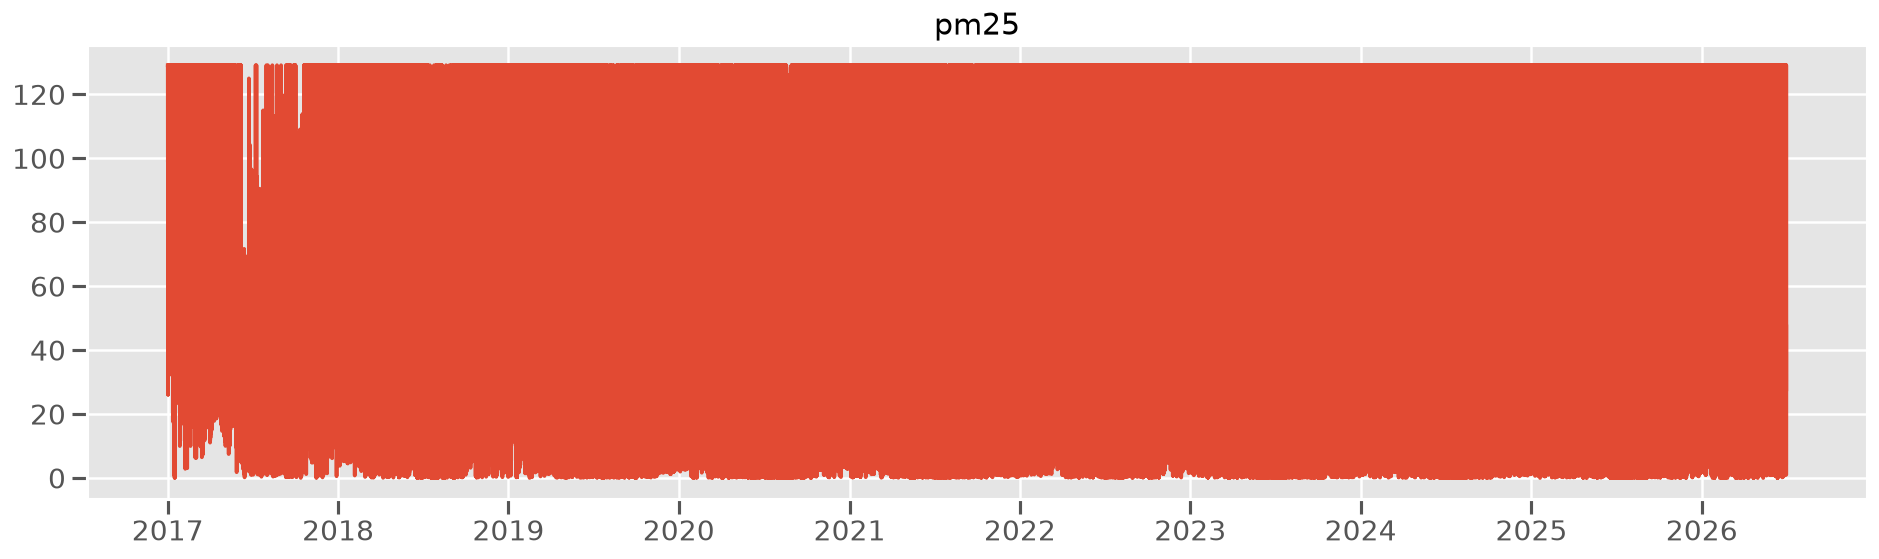

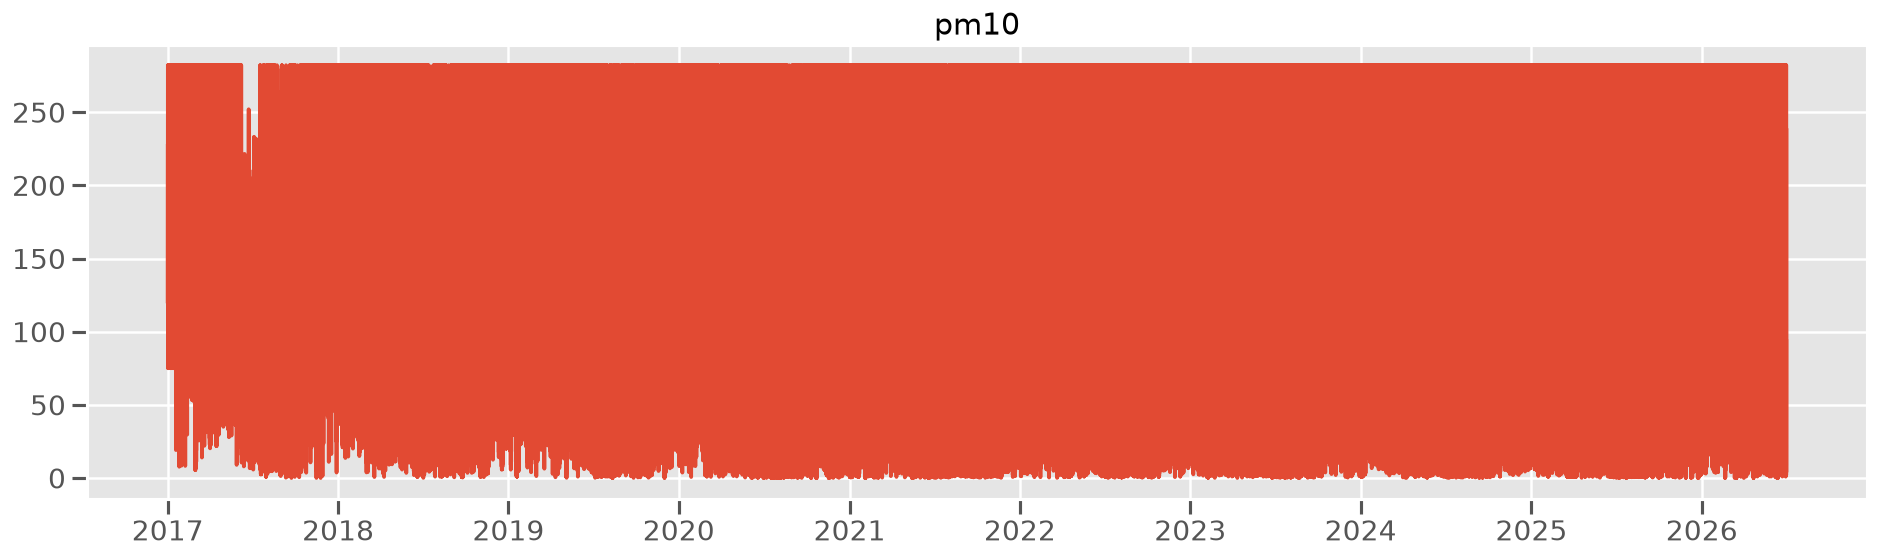

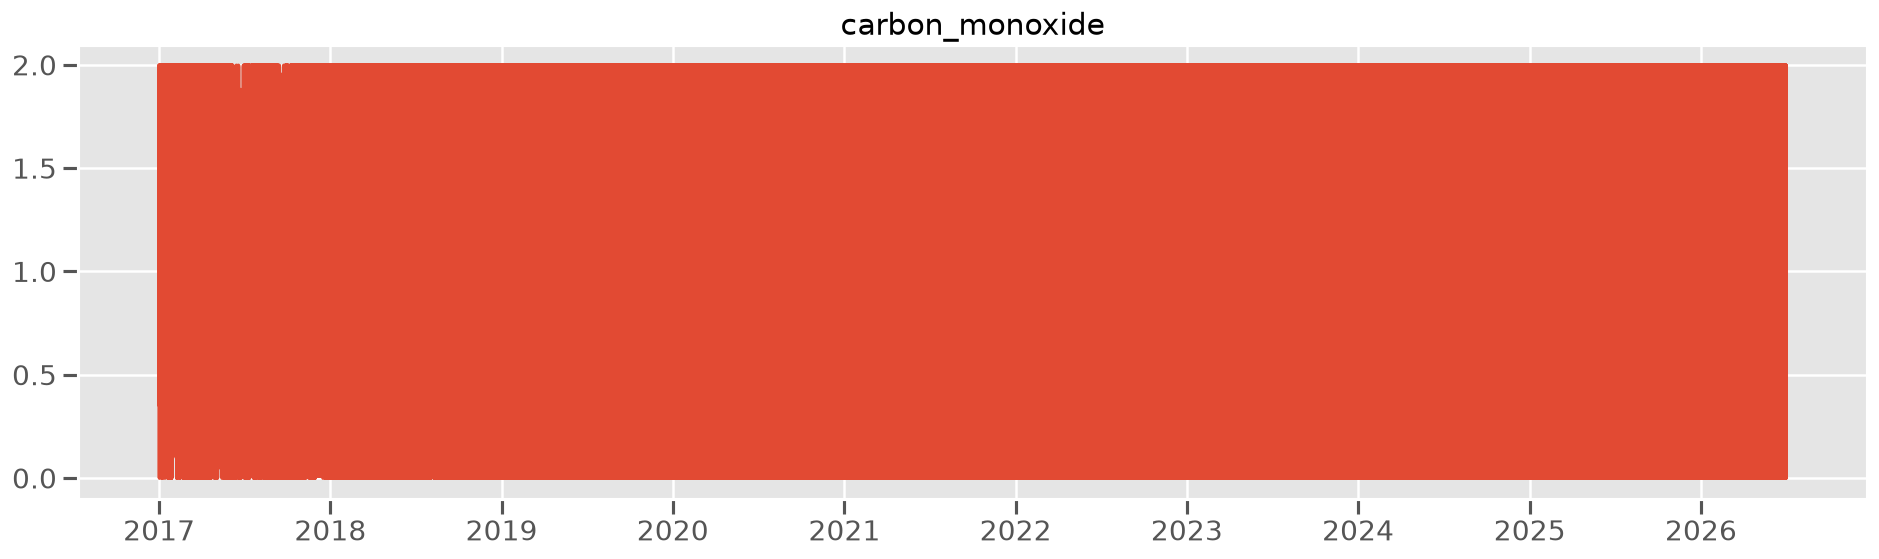

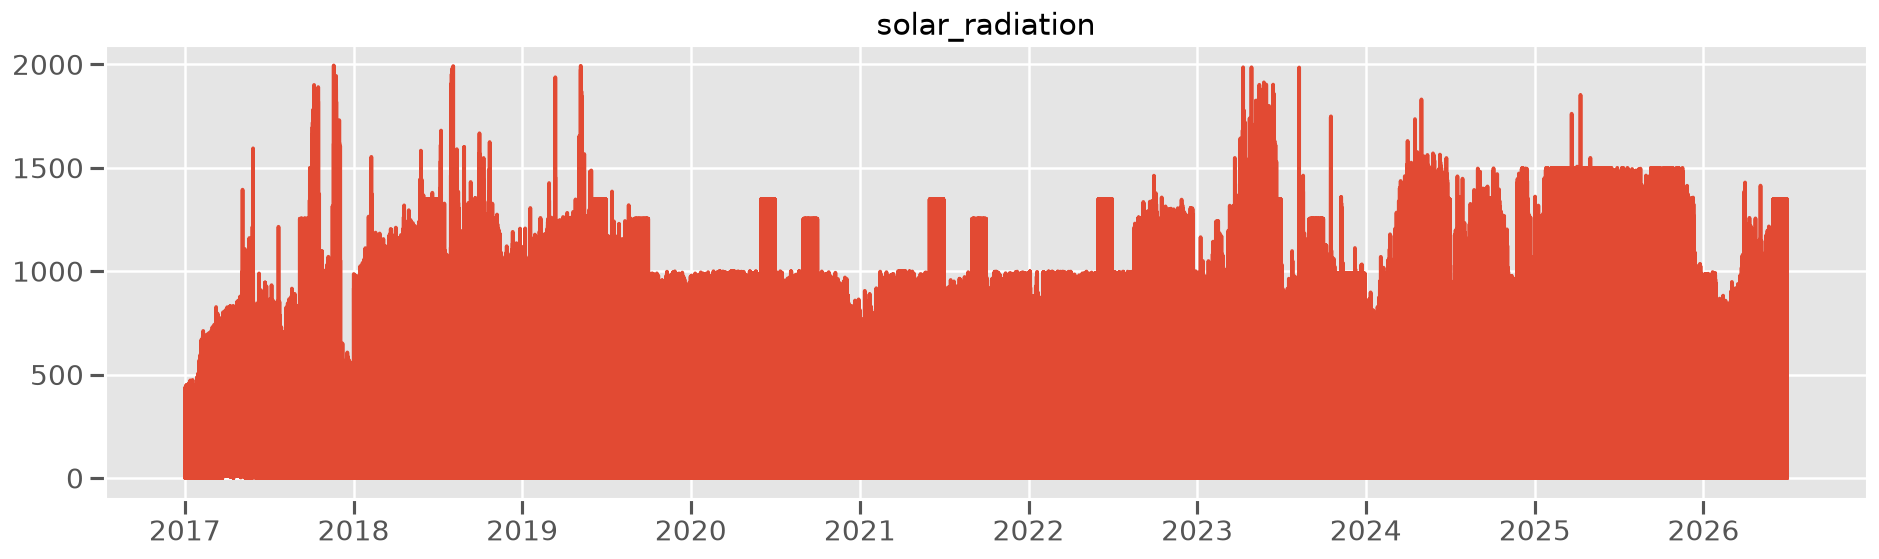

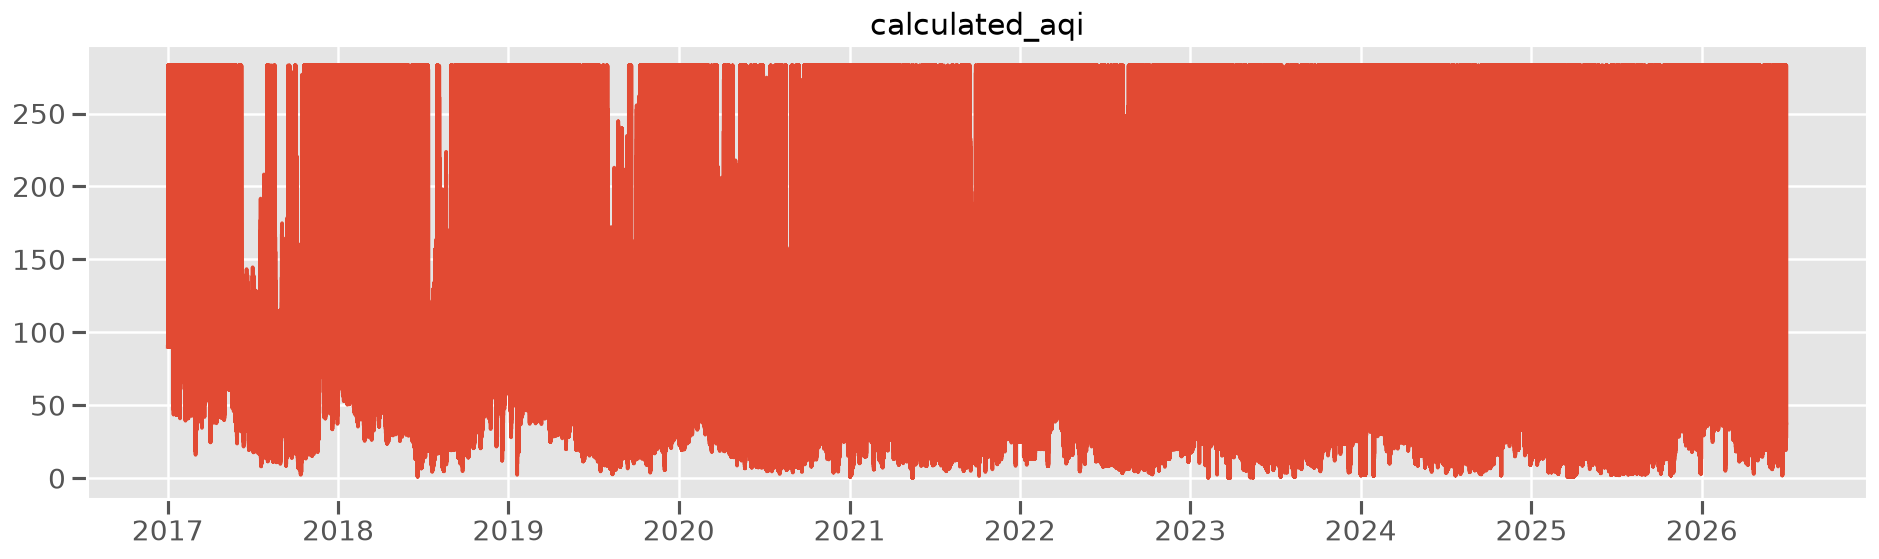

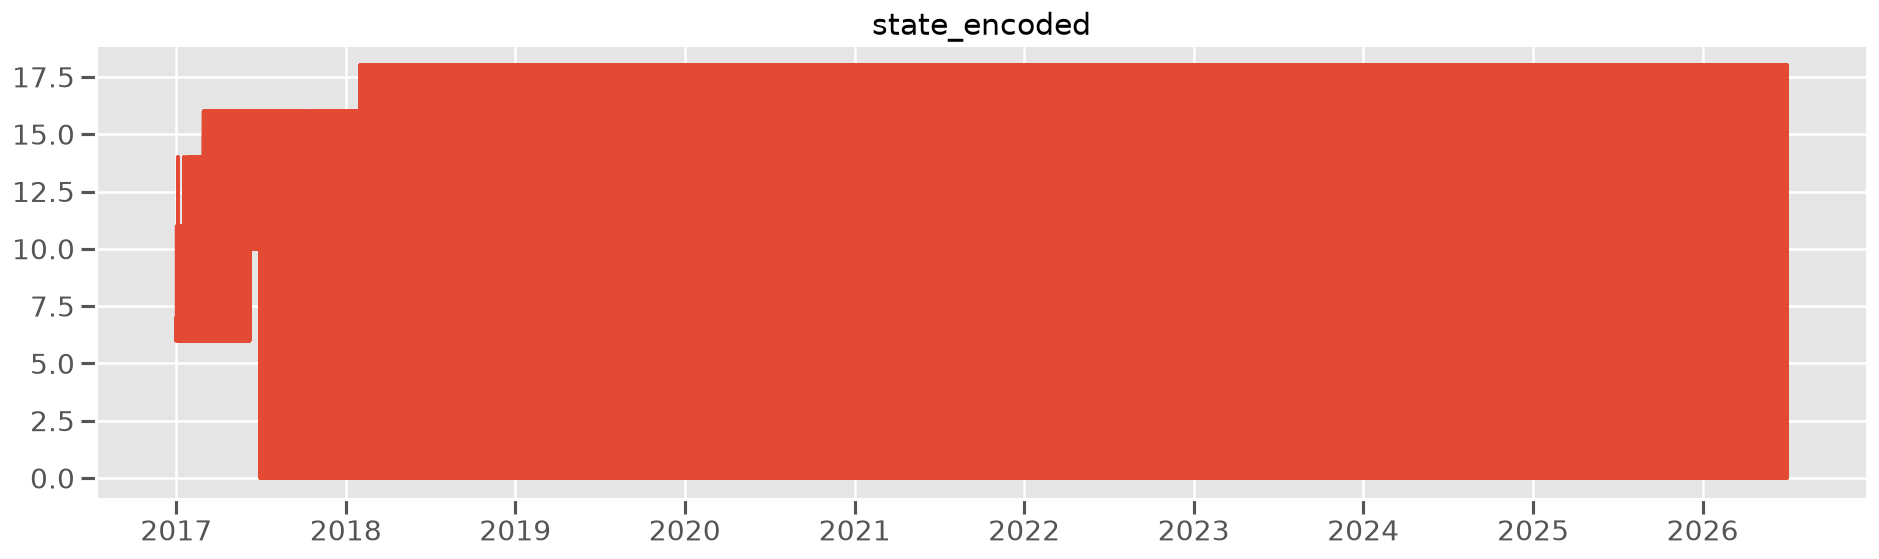

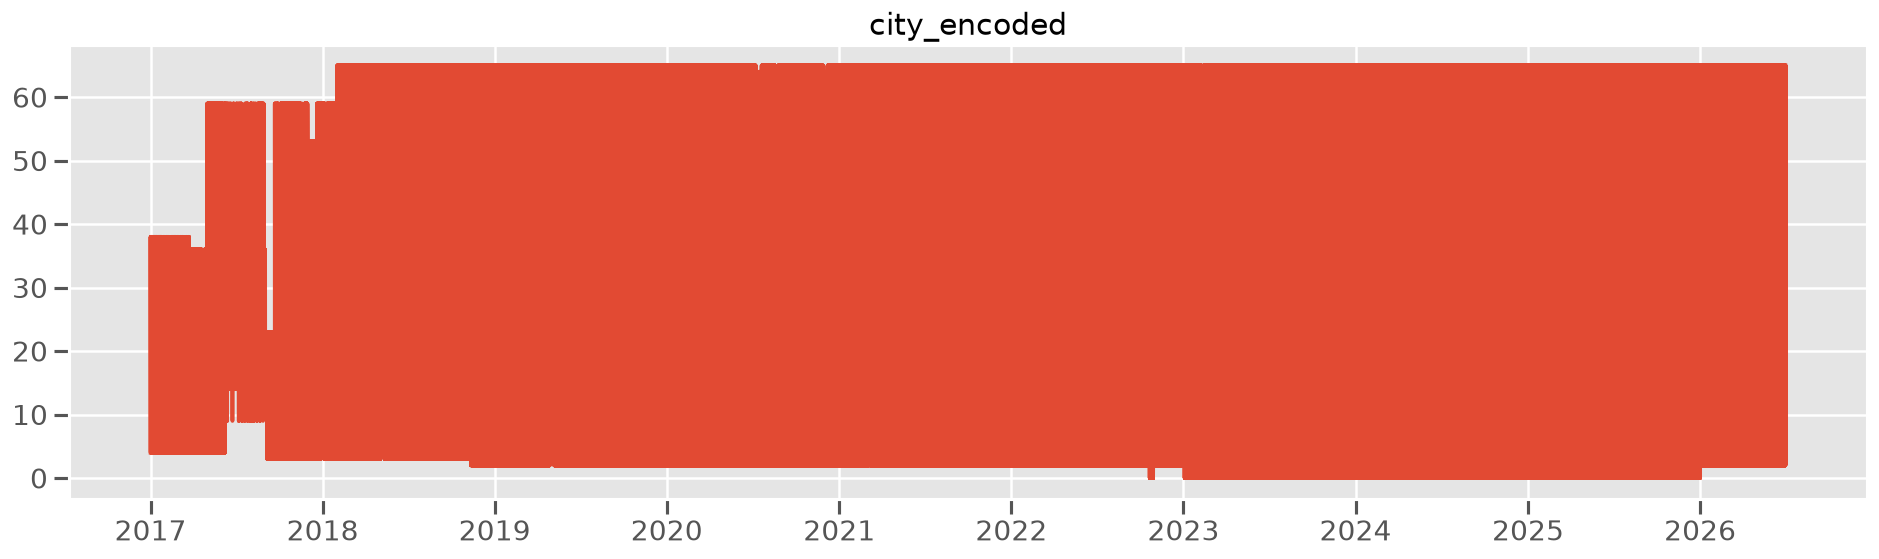

In [14]:
# Pollutant Trend
for col in pollutant_columns:
    plt.figure(figsize=(16,5))
    plt.plot(df["timestamp"], df[col])
    plt.title(col)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR/f"{col}_timeseries.png")
    plt.show()

In [15]:
# Monthly Analysis
df["Month"] = df["timestamp"].dt.month
monthly = df.groupby("Month")[pollutant_columns].mean()
display(monthly)

,pm25,pm10,carbon_monoxide,solar_radiation,calculated_aqi,state_encoded,city_encoded
Month,,,,,,,
1,70.212126,138.595802,0.831821,123.058393,158.951027,9.719397,31.215092
2,59.692699,126.966804,0.789465,145.285252,137.671654,9.729336,31.395257
3,50.044377,114.862944,0.725919,164.709285,119.661654,9.763217,31.407810
4,44.076065,108.892708,0.691554,177.032666,110.699361,9.768143,31.080859
5,39.359405,98.732582,0.692367,186.006227,99.767619,9.758767,30.957135
6,33.619000,86.607199,0.687469,197.549469,87.477532,9.829521,30.827433
7,25.192238,60.069787,0.664094,152.342256,62.166240,9.847492,31.125432
8,25.252899,62.521014,0.650831,159.019857,63.635209,9.897660,31.140668
9,28.195946,65.650959,0.676920,184.695620,66.959389,9.896251,30.790669


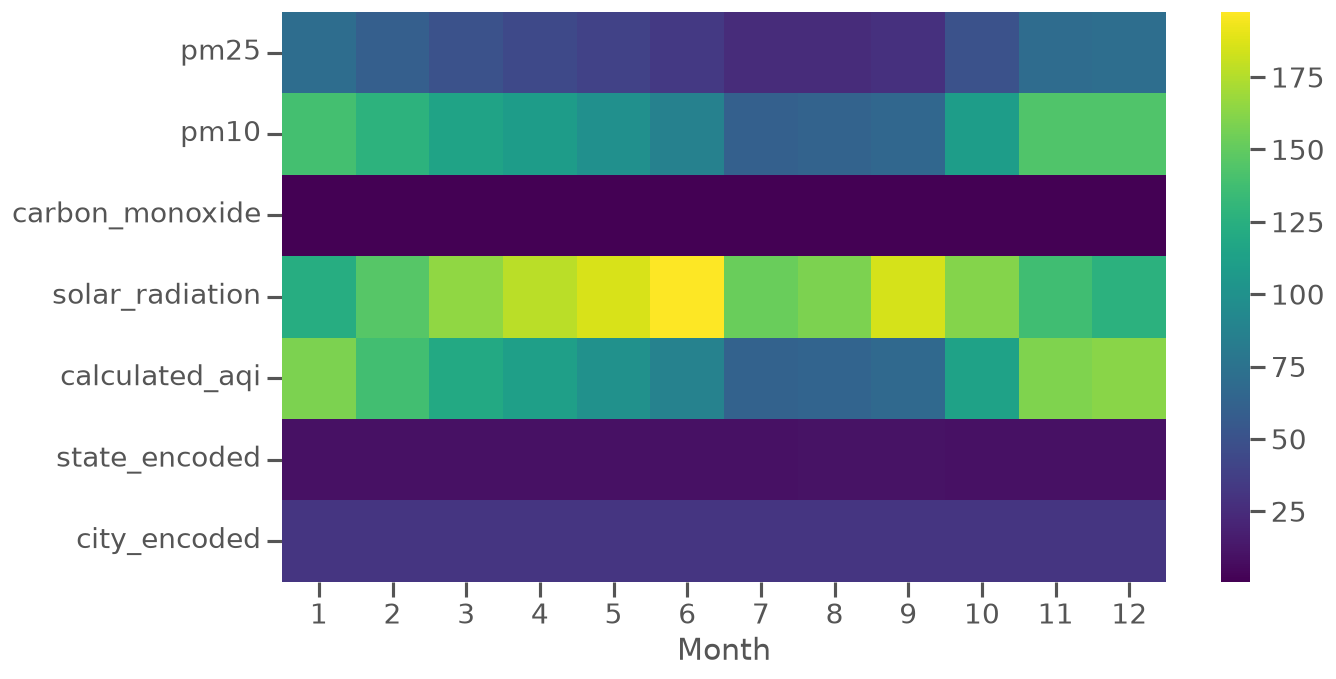

In [16]:
# Monthly Heatmap
sns.heatmap(monthly.T, cmap="viridis")
plt.tight_layout()
plt.savefig(FIGURE_DIR/"monthly_heatmap.png")
plt.show()

In [17]:
# yearly Trend
df["Year"] = df["timestamp"].dt.year
yearly = df.groupby("Year")[pollutant_columns].mean()
display(yearly)

,pm25,pm10,carbon_monoxide,solar_radiation,calculated_aqi,state_encoded,city_encoded
Year,,,,,,,
2017,58.392606,127.192975,0.833738,181.501884,137.108911,9.663814,22.255327
2018,55.006675,121.043276,0.806535,202.420764,131.046470,9.793250,24.910202
2019,53.664596,116.904081,0.811710,209.338230,127.061676,10.188338,28.109797
2020,45.824957,97.395067,0.766634,187.849017,105.091245,10.629059,31.647063
2021,49.696664,108.928176,0.834641,177.294313,117.215402,10.590901,32.363939
2022,50.174283,114.092834,0.812642,158.621221,121.601140,9.941424,32.618127
2023,46.656326,106.330887,0.800484,144.263608,112.268267,9.387284,31.869920
2024,45.136097,99.989896,0.721186,134.488200,106.465924,9.289406,31.499092
2025,42.344344,93.930443,0.703400,135.692680,99.700155,9.351429,30.614741


In [18]:
# Daily Pattern
if "timestamp" in df.columns:
    df["Hour"] = df["timestamp"].dt.hour
    hourly = df.groupby("Hour")[pollutant_columns].mean()
    display(hourly)

,pm25,pm10,carbon_monoxide,solar_radiation,calculated_aqi,state_encoded,city_encoded
Hour,,,,,,,
0,52.609157,115.478063,0.797770,69.007085,113.037100,9.806881,31.013787
1,51.439547,110.861694,0.756621,69.431212,113.063536,9.808024,31.001700
2,49.945656,106.004454,0.726120,69.709087,113.080668,9.810798,30.995543
3,48.742967,102.238578,0.711340,70.046682,113.193688,9.798536,30.954667
4,47.847741,99.655473,0.702743,70.514357,113.181901,9.799344,30.988222
5,47.392805,98.822868,0.712737,73.737932,113.135109,9.796999,30.998656
6,47.928157,100.883702,0.741454,97.007687,113.075153,9.790472,31.012781
7,49.451889,105.572973,0.774152,150.870923,112.735028,9.780733,31.088878
8,51.022607,110.223860,0.770274,223.653688,112.632704,9.776169,31.140764


In [19]:
# City wise Analysis
city_columns = [c for c in df.columns if "city" in c.lower()]
if city_columns:
    city = city_columns[0]
    city_summary = df.groupby(city)[pollutant_columns].mean()
    display(city_summary)

,pm25,pm10,carbon_monoxide,solar_radiation,calculated_aqi,state_encoded,city_encoded
city,,,,,,,
"32Bungalows, Bhilai (, )",27.670712,58.446416,0.564323,137.935617,59.369991,5.0,0.0
"AIIMS, Raipur (, )",27.413309,68.796529,0.755419,144.106443,68.224655,5.0,1.0
"Alipur (, )",75.706617,171.434166,0.932978,149.525701,185.760045,6.0,2.0
"Anand Kala Kshetram, Rajamahendravaram (, )",33.977068,71.136386,0.635502,192.485718,76.718147,0.0,3.0
"Anand Vihar ( , )",87.641121,215.681331,1.552462,192.771540,220.354587,6.0,4.0
...,...,...,...,...,...,...,...
"Thavakkara, Kannur (, )",33.533544,62.892428,0.528688,175.105120,65.198062,12.0,61.0
"Udyogamandal, Eloor (, )",25.811691,51.853747,0.800145,57.780000,55.422255,12.0,62.0
"Vidayagiri, Bagalkot (, )",23.020130,47.979148,0.519723,193.356729,49.880271,11.0,63.0


In [20]:
# Skewness & Kurtosis
summary = pd.DataFrame({
    "Skewness":df[numeric_columns].skew(),
    "Kurtosis":df[numeric_columns].kurt()
})

display(summary)

,Skewness,Kurtosis
pm25,1.043432,0.094878
pm10,1.035286,0.134591
nitric_oxide,1.111605,0.019265
nitrogen_dioxide,1.019964,0.051582
nitrogen_oxides,1.013684,0.152883
ammonia,0.932891,0.004947
sulfur_dioxide,1.017957,0.091802
carbon_monoxide,0.843396,-0.007998
ozone,1.042579,0.128112
ambient_temperature,-0.492505,1.372841


In [21]:
# Outlier Percentage
outlier_report = {}
for col in pollutant_columns:
    q1 = df[col].quantile(.25)
    q3 = df[col].quantile(.75)
    iqr = q3-q1
    lower = q1-1.5*iqr
    upper = q3+1.5*iqr
    outlier_report[col] = ((df[col]<lower)|(df[col]>upper)).mean()*100

display(pd.DataFrame.from_dict(outlier_report, orient="index", columns=["Outlier %"]))

,Outlier %
pm25,0.000000
pm10,6.627181
carbon_monoxide,6.667600
solar_radiation,7.618194
calculated_aqi,0.000000
state_encoded,0.000000
city_encoded,0.000000


In [22]:
# Feature Summary Report
feature_report = pd.DataFrame({
    "dtype":df.dtypes,
    "missing":df.isnull().sum(),
    "unique":df.nunique()
})
display(feature_report)

,dtype,missing,unique
timestamp,datetime64[us],0,83231
pm25,float64,0,132928
pm10,float64,0,185038
nitric_oxide,float64,0,76963
nitrogen_dioxide,float64,0,103425
nitrogen_oxides,float64,0,86898
ammonia,float64,0,91327
sulfur_dioxide,float64,0,85984
carbon_monoxide,float64,0,33769
ozone,float64,0,113858


In [23]:
# Save Reports
feature_report.to_csv(REPORT_DIR/"feature_summary.csv")
summary.to_csv(REPORT_DIR/"distribution_summary.csv")
monthly.to_csv(REPORT_DIR/"monthly_pollution_summary.csv")